In [19]:
import numpy as np
import matplotlib . pyplot as plt
# --- Physical parameters ( Table 1) ---
Lx , Ly = 600 *1e3 , 240* 1e3 # domain size [ m ]
Nx , Ny = 256 , 102 # grid resolution
g_prime = 0.3 # reduced gravity [ m / s ^2]
H0 = 1000.0 # mean layer depth [ m ]
U0 = 8.0 # inflow wind speed [ m / s ]
R0 = 20 *1e3 # island radius [ m ]
Cd = 0.02 # drag coefficient [1/ s ]
nu = 1000.0 # eddy viscosity [ m ^2/ s ]
dt = 30.0 # time step [ s ]
# --- Grid : x has walls ( keep endpoints ) , y is periodic ( drop last point ) ---
x = np . linspace (0 , Lx , Nx )
y = np . linspace (0 , Ly , Ny , endpoint = False )
dx = x [1] - x [0]
dy = y [1] - y [0]
X , Y = np . meshgrid (x , y ) # shape ( Ny , Nx ) : x along columns , y along rows
# --- Initial fields ---
rng = np.random.default_rng(0)
h = np.full (( Ny , Nx ) , H0 )
u = np.full (( Ny , Nx ) , U0 ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
v = np.zeros (( Ny , Nx ) ) + 1*1e-3* U0 * rng.standard_normal (( Ny , Nx ) )
# --- Gaussian mountain mask C (x , y ) , centred at ( Lx /3 , Ly /2) ---
xc , yc = Lx /3 , Ly /2
C = np.exp ( -((( X - xc ) **2 + ( Y - yc ) **2) / (0.35* R0 ) **2) )



In [20]:
def ddx ( q ) :
    out = np . zeros_like ( q )
    out [: , 1: -1] = ( q [: , 2:] - q [: , : -2]) / (2* dx ) # central , O (dx ^2)
    out [: , 0] = ( q [: , 1] - q [: , 0]) / dx # forward at x = 0
    out [: , -1] = ( q [: , -1] - q [: , -2]) / dx # backward at x = Lx
    return out
def ddy ( q ) :
# y is periodic -> centred difference with np . roll along the rows
    return ( np . roll (q , -1 , axis =0) - np . roll (q , 1 , axis =0) ) / (2* dy )
def laplacian ( q ) :
    d2x = np . zeros_like ( q )
    d2x [: , 1: -1] = ( q [: , 2:] - 2* q [: , 1: -1] + q [: , : -2]) / dx **2
    d2x [: , 0] = ( q [: , 0] - 2* q [: , 1] + q [: , 2]) / dx **2 # one - sided wall
    d2x [: , -1] = ( q [: , -1] - 2* q [: , -2] + q [: , -3]) / dx **2 # one - sided wall
    d2y = ( np . roll (q , -1 , axis =0) - 2* q + np . roll (q , 1 , axis =0) ) /dy **2
    return d2x + d2y

In [21]:
q = np . sin (2* np . pi * X / Lx )
num = ddx ( q )
ana = (2* np . pi / Lx ) * np . cos (2* np . pi * X / Lx )
print ( " max relative error : " , np . abs ( num - ana ) . max () / (2* np . pi / Lx ) )

 max relative error :  0.00010118472178036849


In [22]:
def rhs(h,u,v):
    
    dh_dt = -ddx(h*u) - ddy(h*v)

    du_dt = (-u * ddx(u)
               - v * ddy(u)
               - g_prime * ddx(h)
               + nu * laplacian(u)
               - Cd * C * u)
    
    dv_dt = (-u * ddx(v)
               - v * ddy(v)
               - g_prime * ddy(h)
               + nu * laplacian(v)
               - Cd * C * v)
    
    return dh_dt, du_dt, dv_dt

    

In [23]:
def rk2_step(h, u, v):
      
      dh1, du1, dv1 = rhs(h, u, v)

      h1 = h + dt * dh1
      u1 = u + dt * du1
      v1 = v + dt * dv1

      
      dh2, du2, dv2 = rhs(h1, u1, v1)
      h2 = h + dt/2 * (dh1 + dh2)
      u2 = u + dt/2 * (du1 + du2)
      v2 = v + dt/2 * (dv1 + dv2)

      return h2, u2, v2


def boundary_conditions(h, u, v):
      #west
      u[:, 0] = U0
      v[:, 0] = 00
      h[:, 0] = H0

      #east
      u[:, -1] = u[:, -2]
      v[:, -1] = v[:, -2]
      h[:, -1] = h[:, -2]

      return h, u ,v
    

In [31]:
def update_rk2(h,u,v, steps = 60000):
    for n in range(steps):
        h, u, v = rk2_step(h,u,v)
        h, u, v = boundary_conditions(h,u,v)

        if n % 500 == 0:
              zeta = ddx(v) - ddy(u)
              plt.figure(figsize=(12, 4))
              plt.contourf(X/1e3, Y/1e3, zeta, levels=50, cmap='seismic') #RdBu_r
              plt.colorbar(label='vorticity [1/s]')
              plt.xlabel('x [km]')
              plt.ylabel('y [km]')
              plt.tight_layout()
              plt.show()

        
    return h, u, v










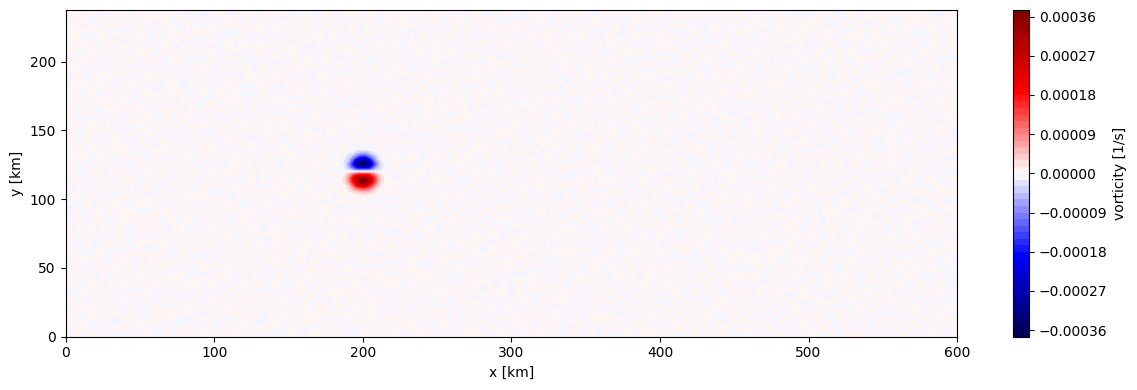

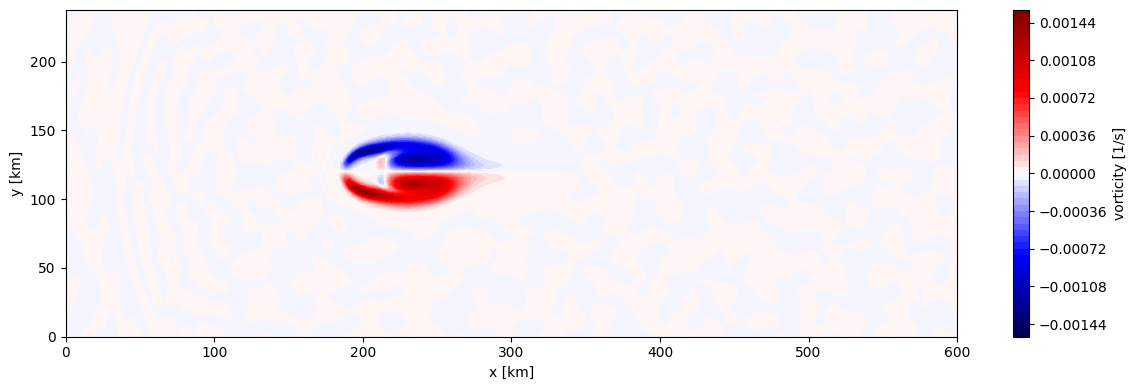

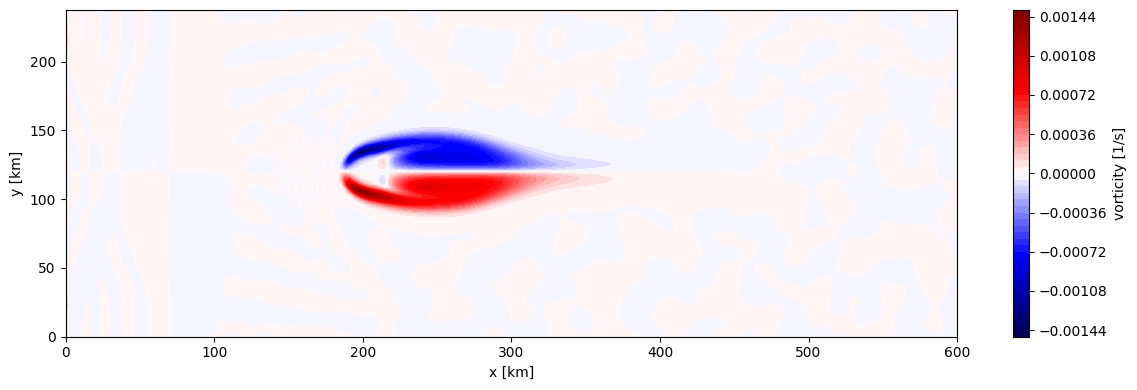

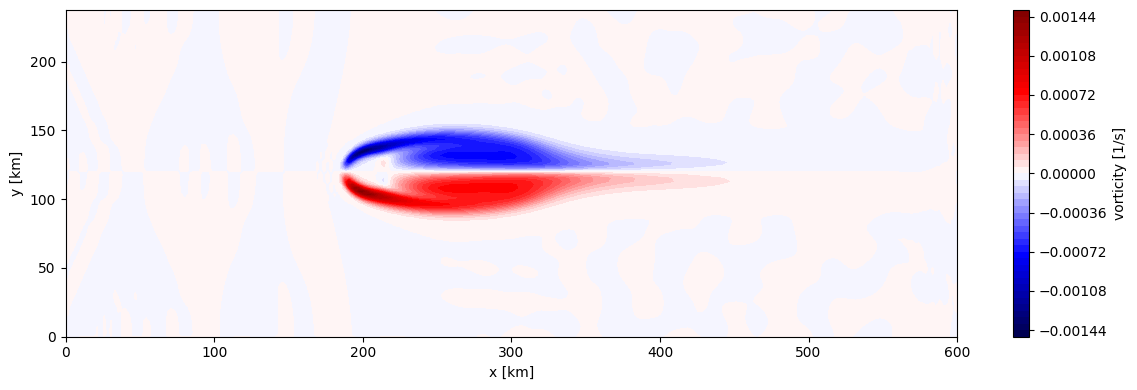

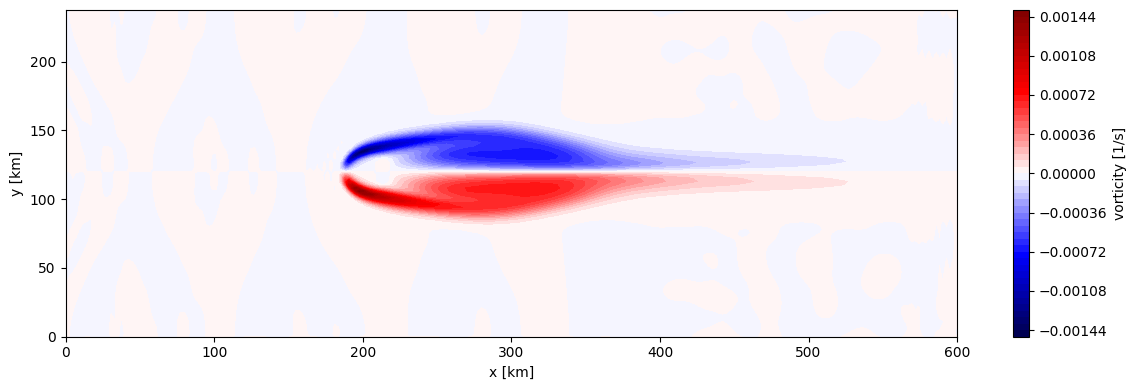

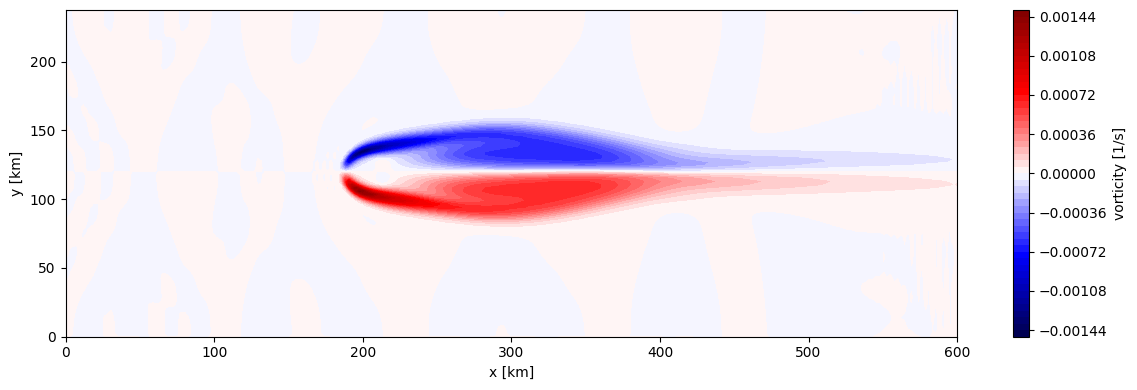

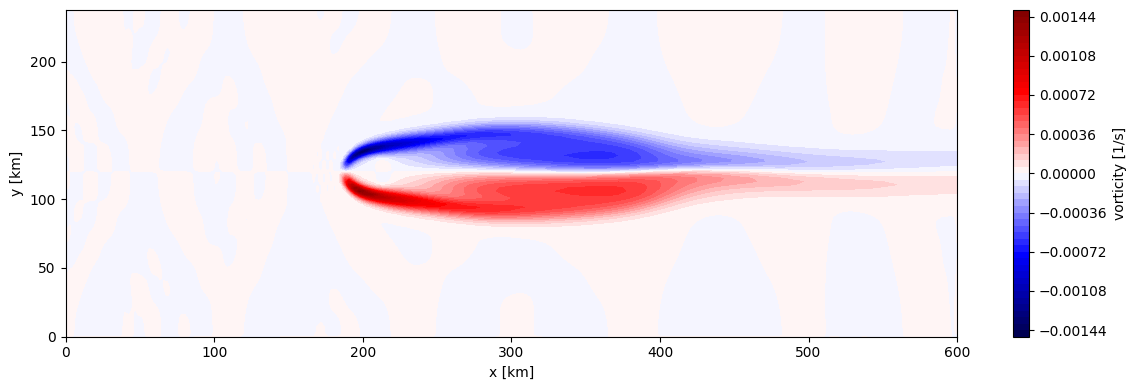

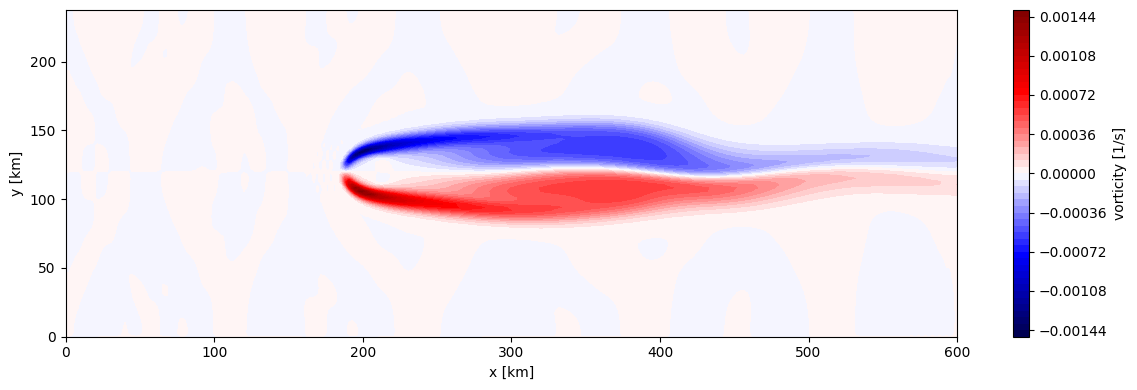

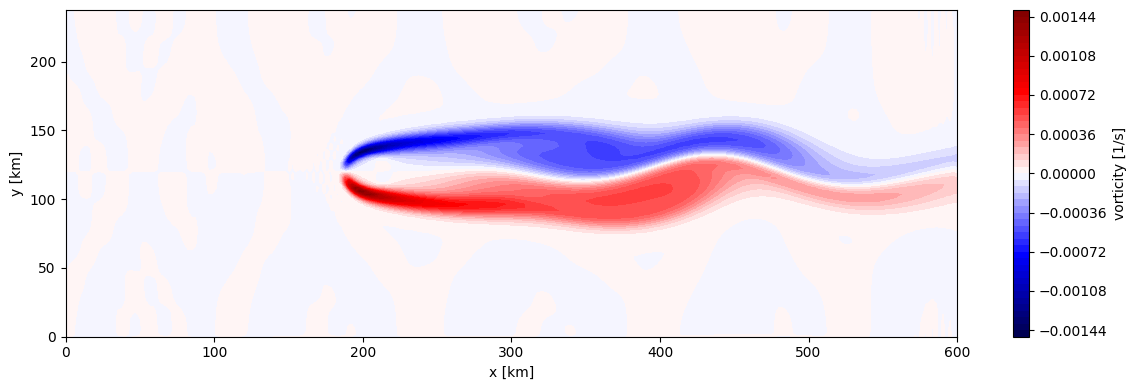

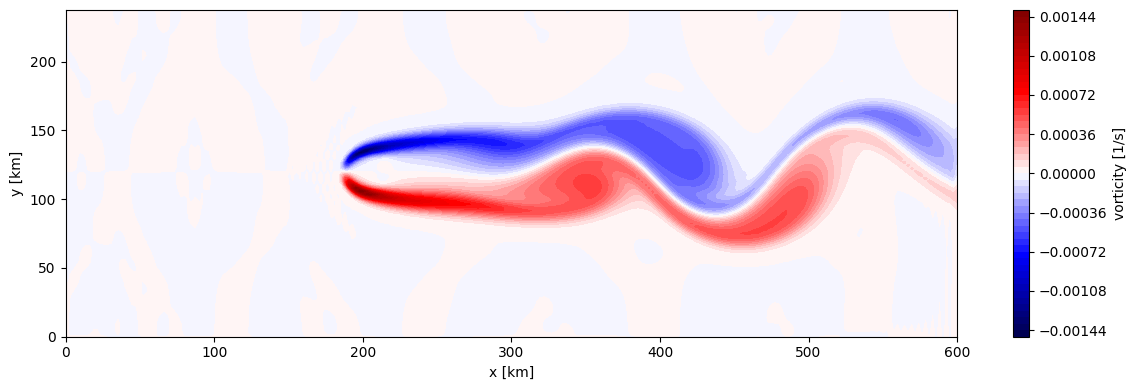

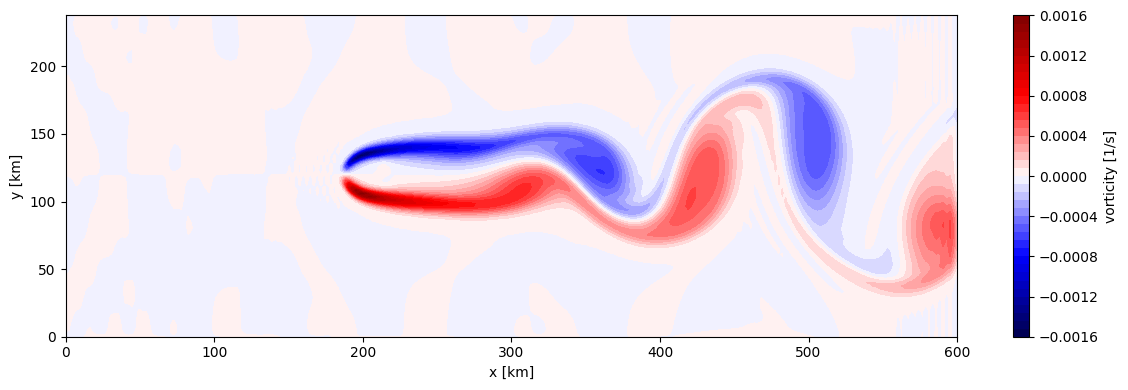

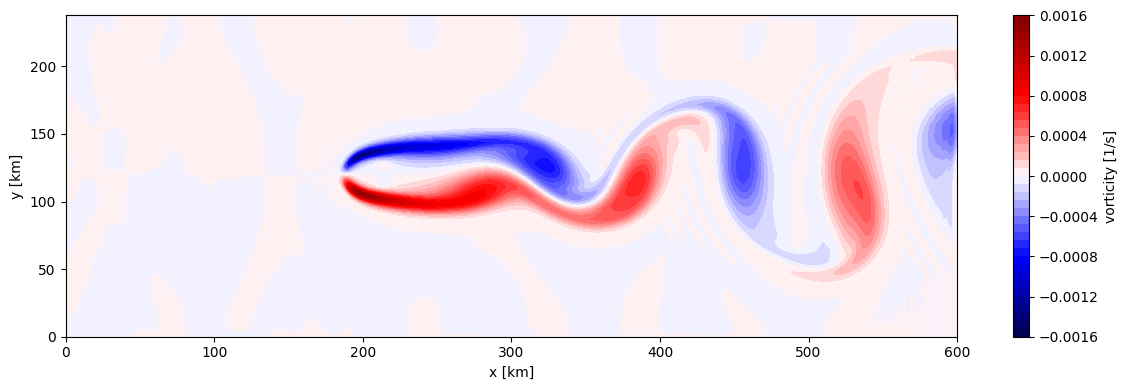

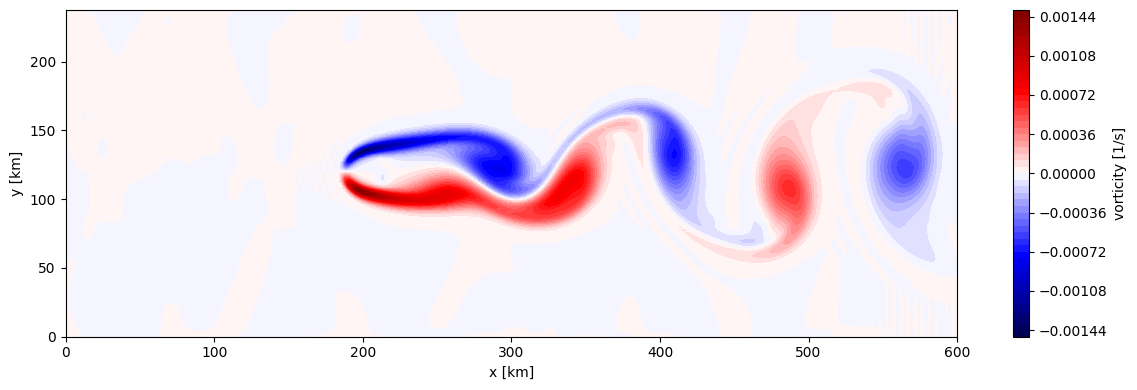

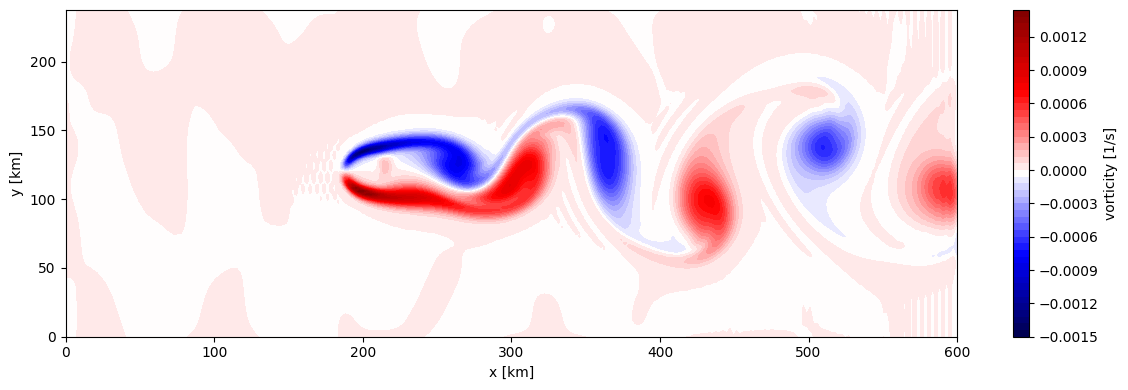

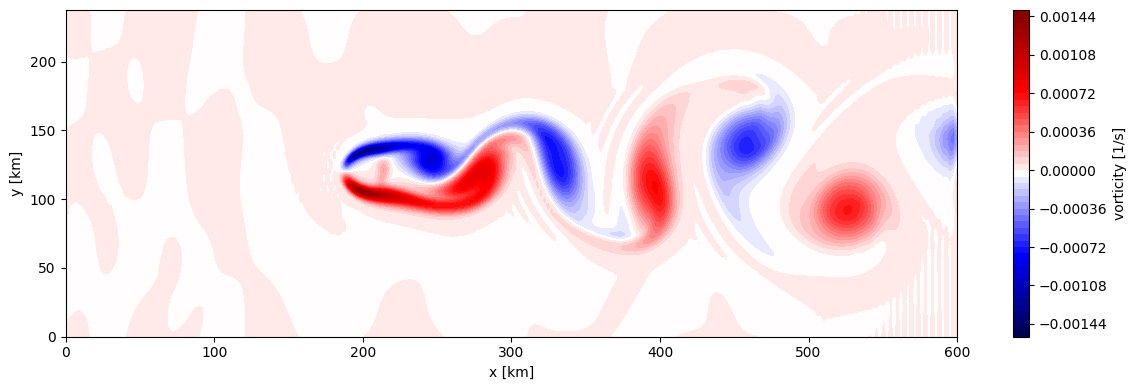

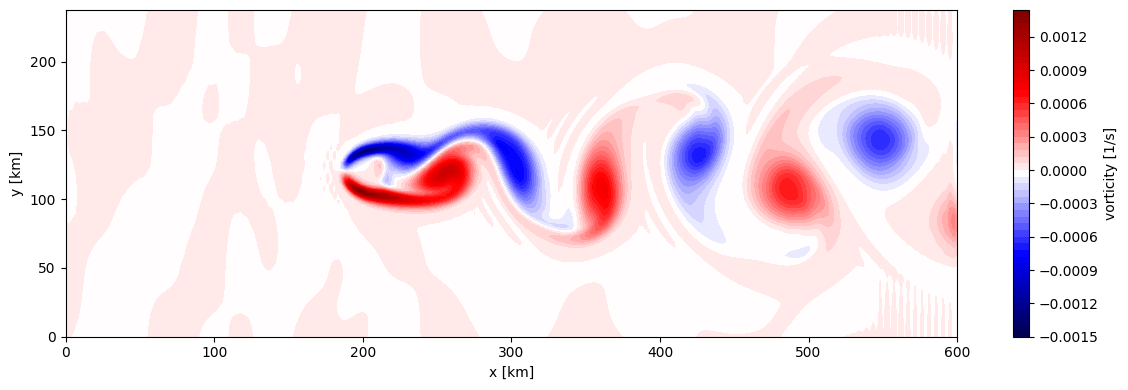

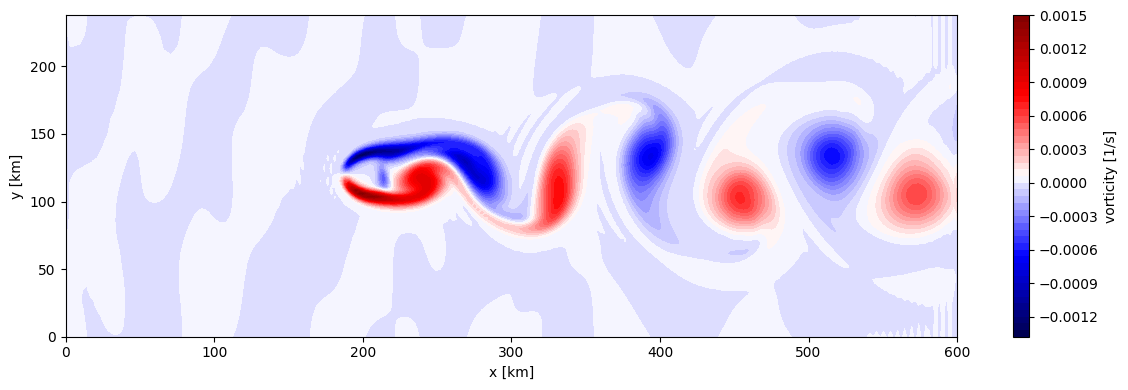

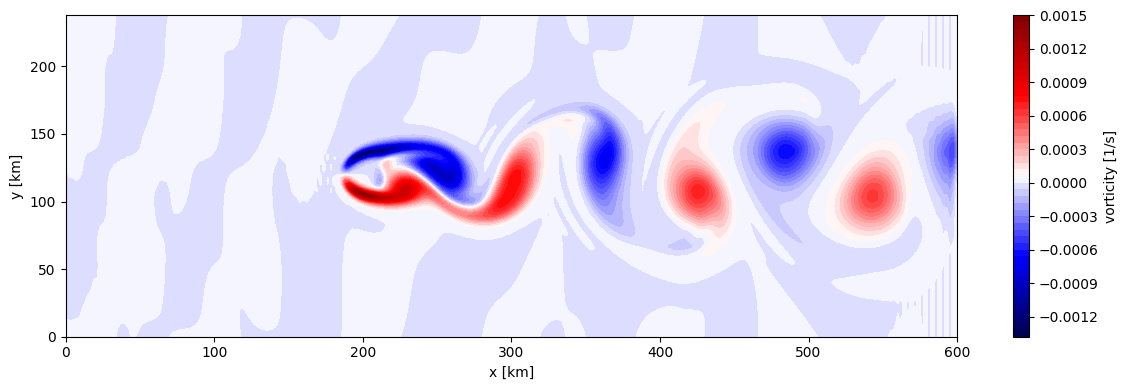

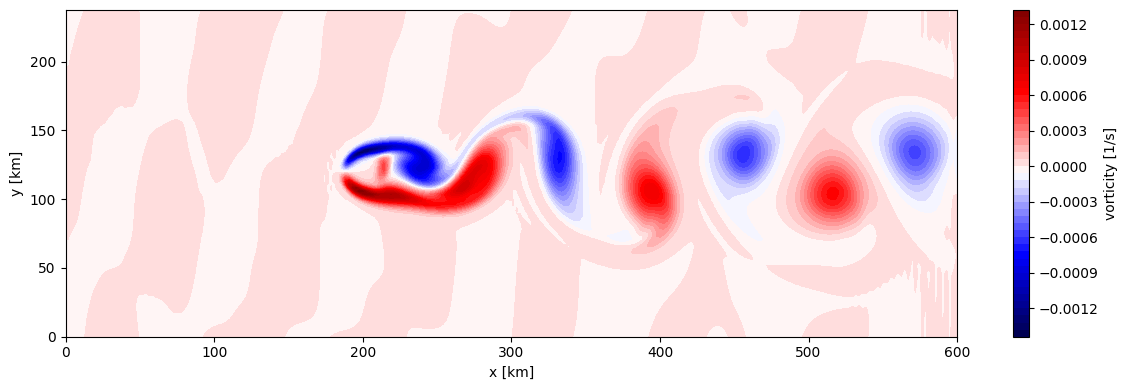

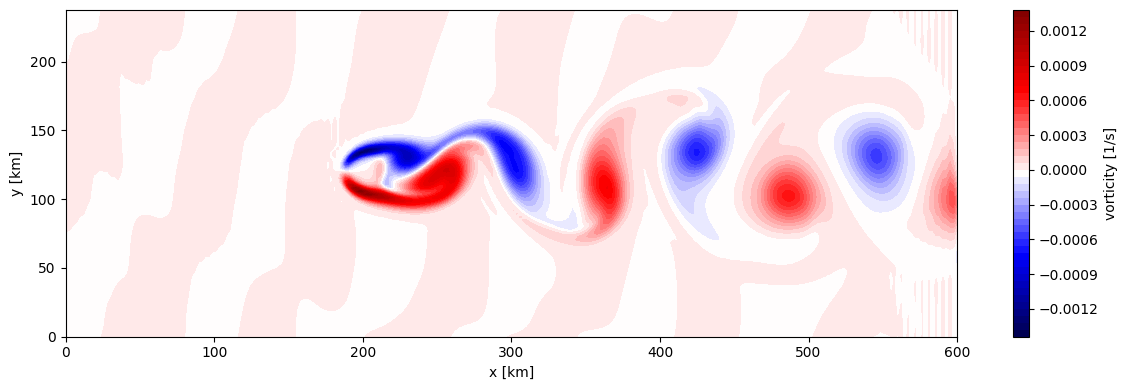

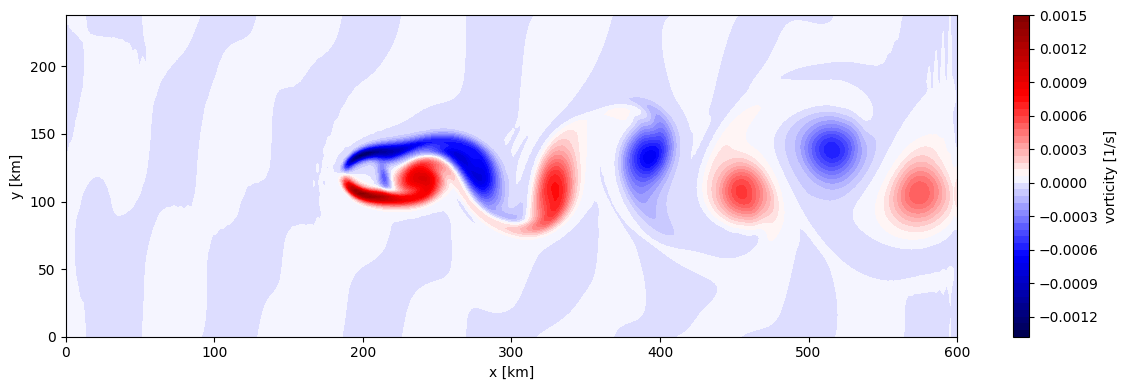

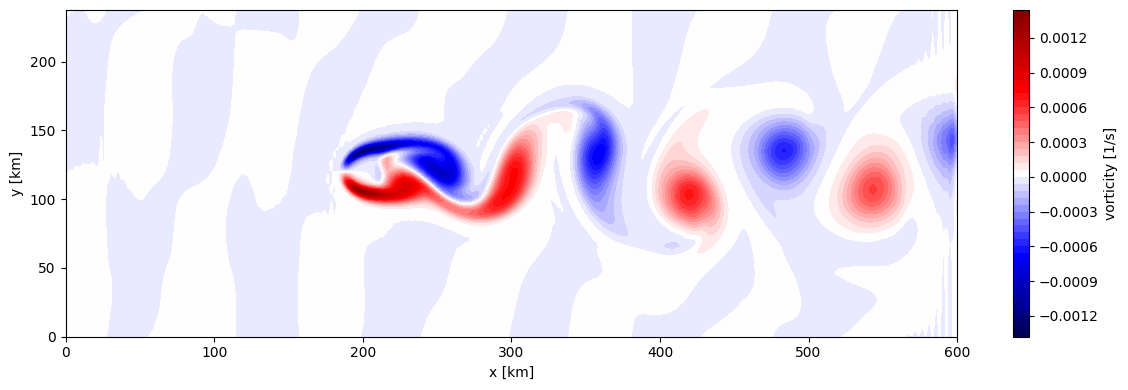

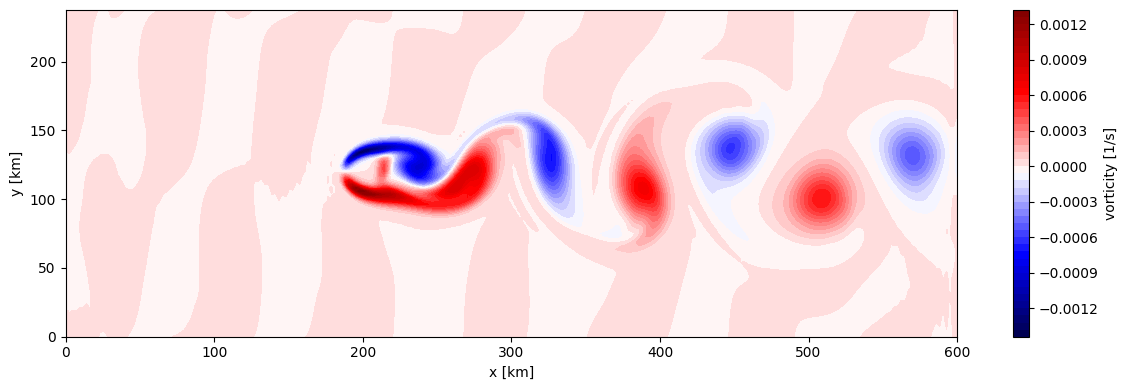

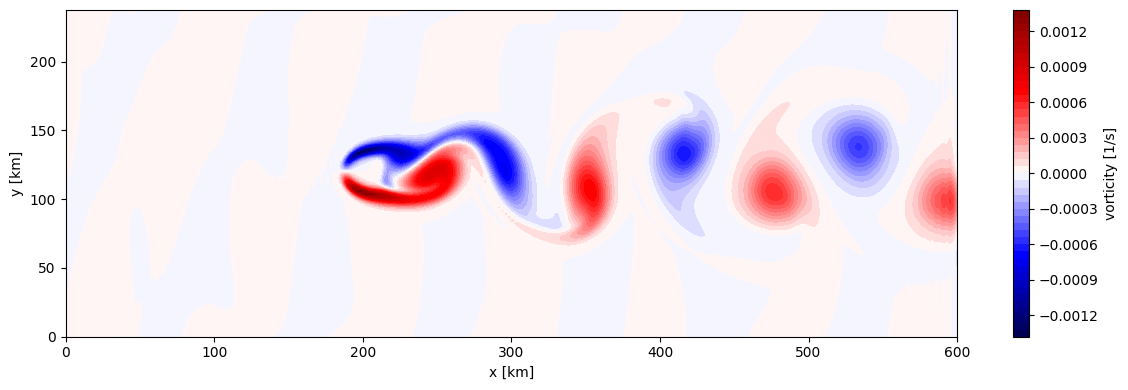

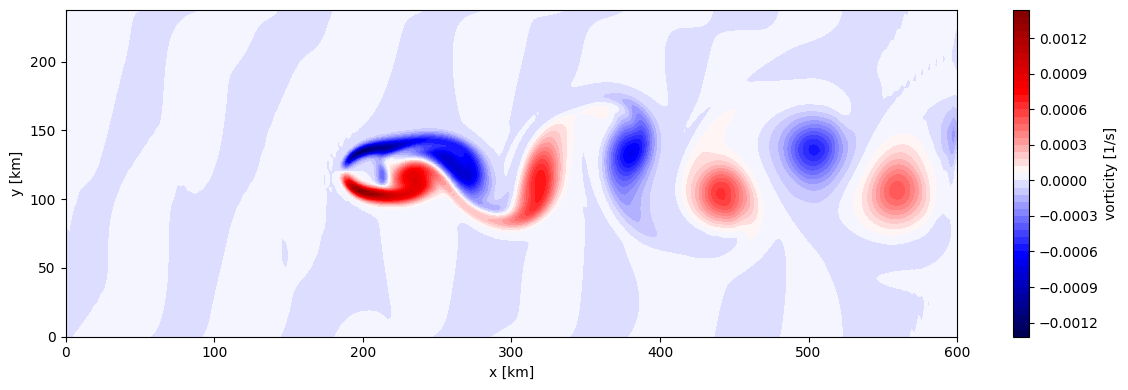

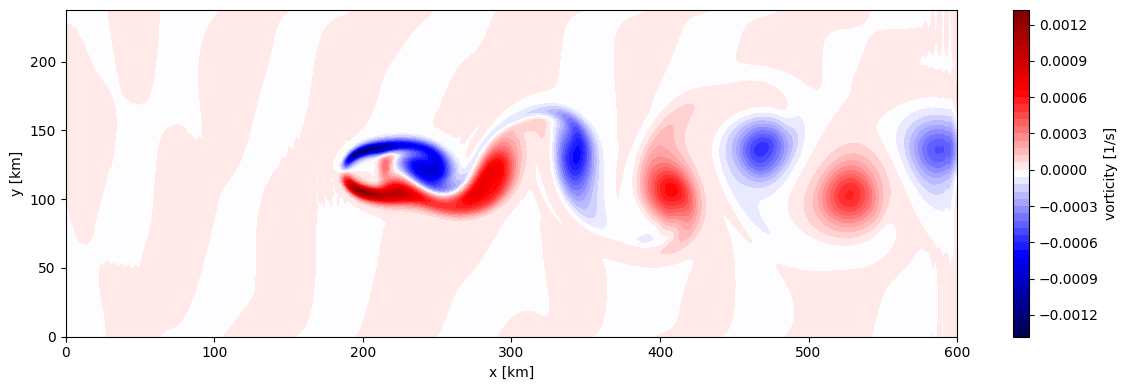

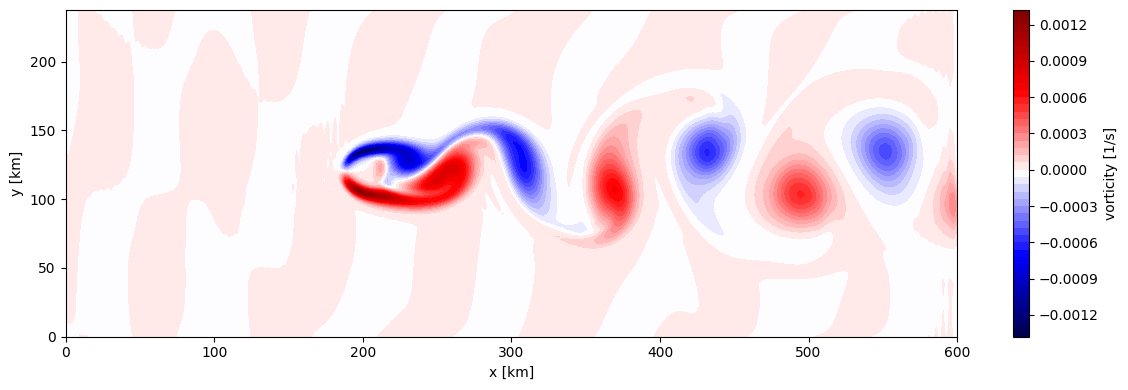

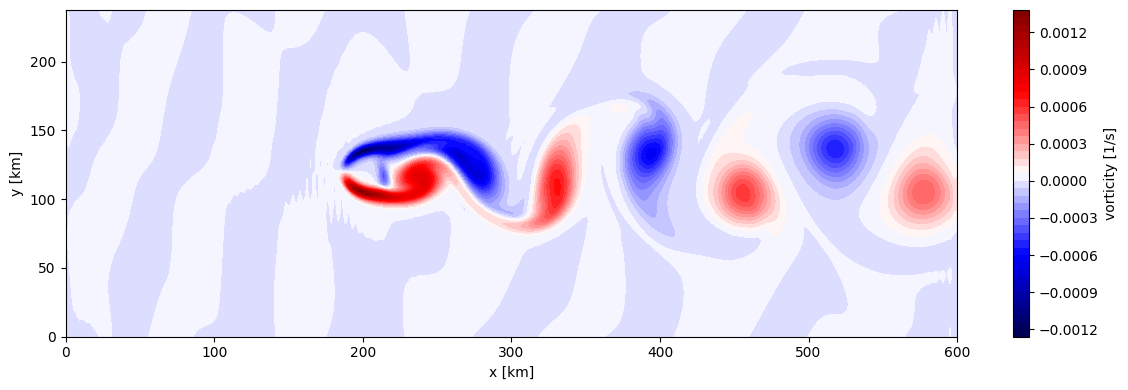

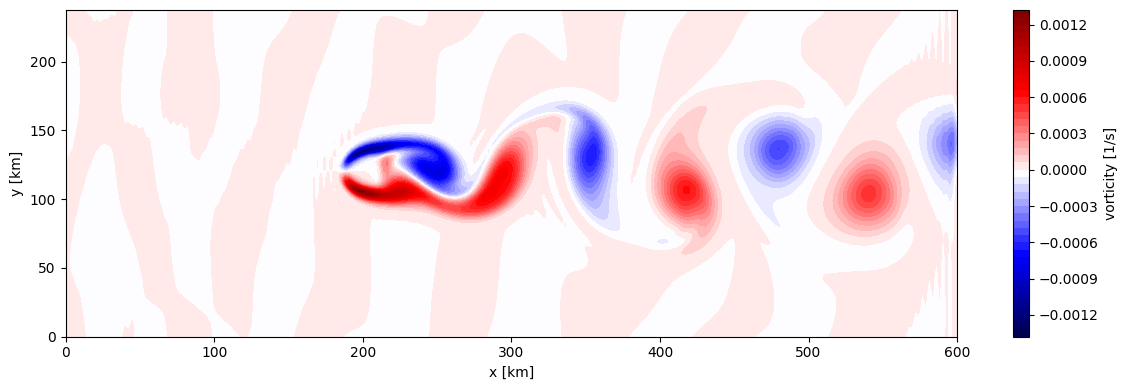

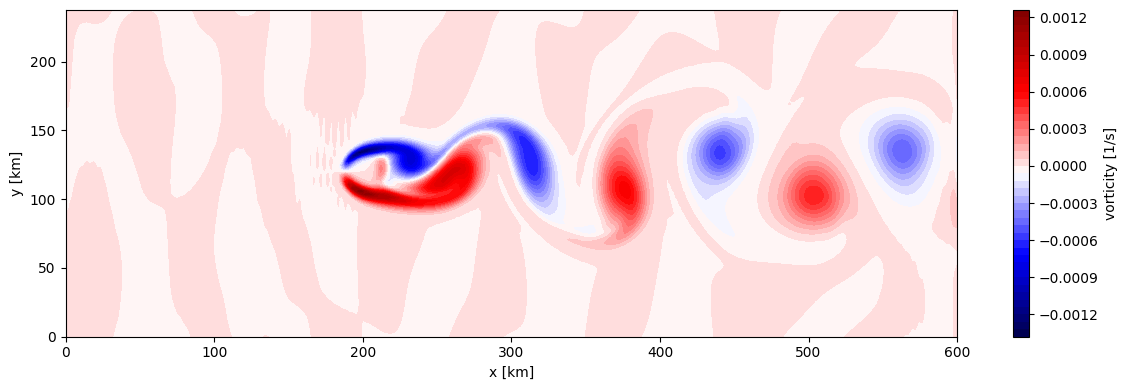

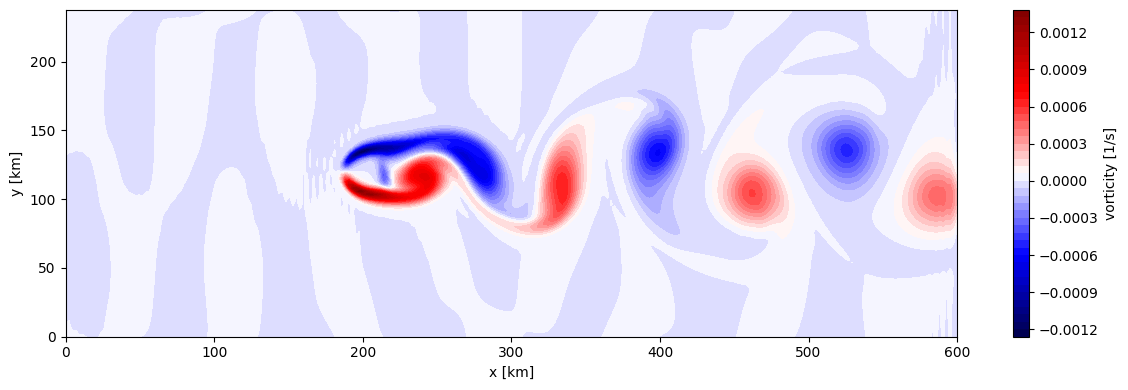

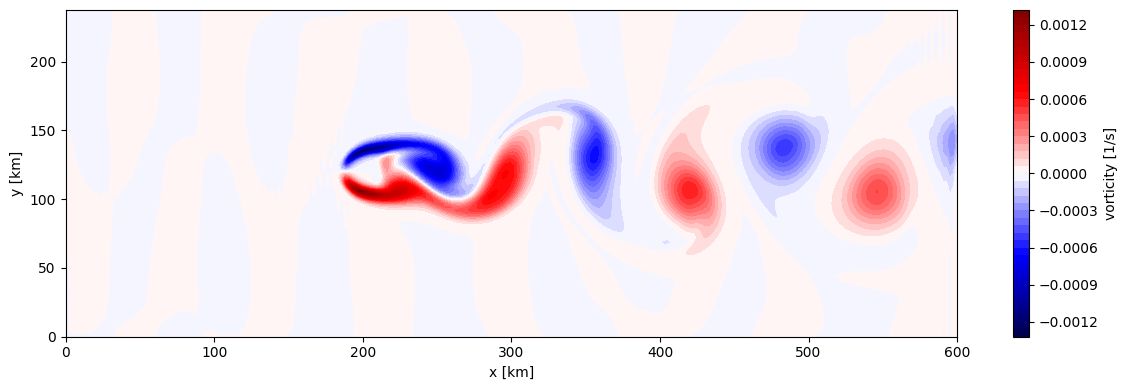

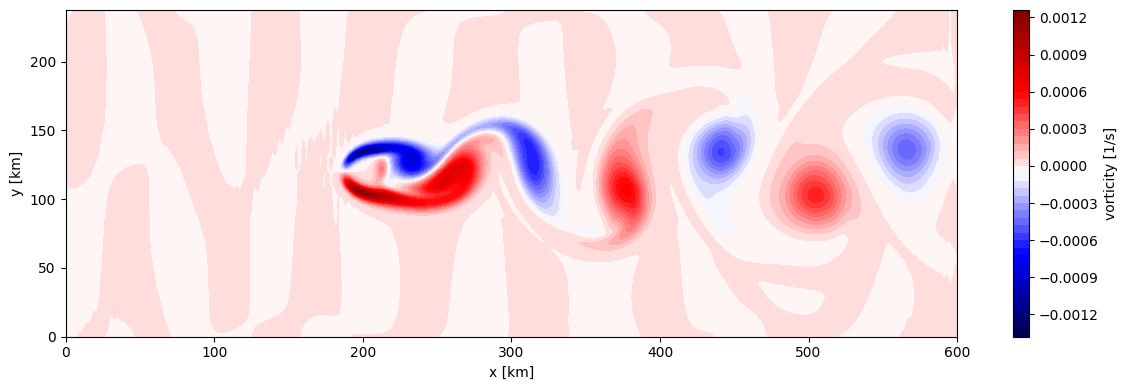

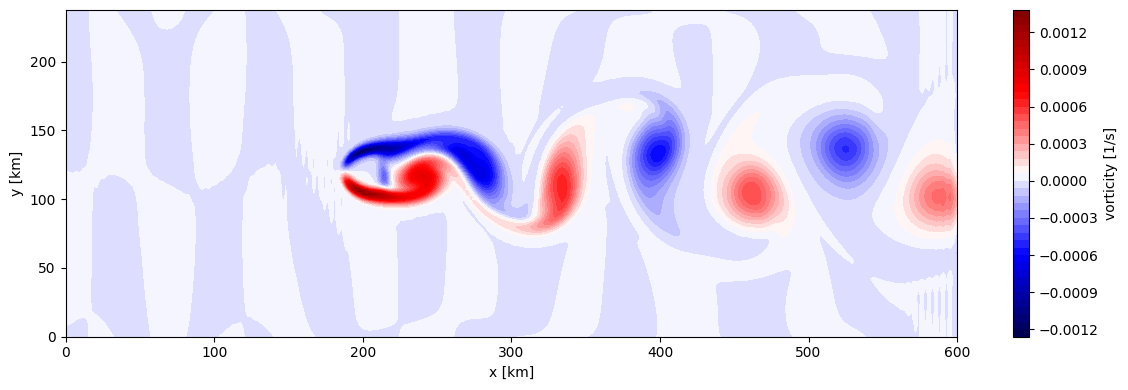

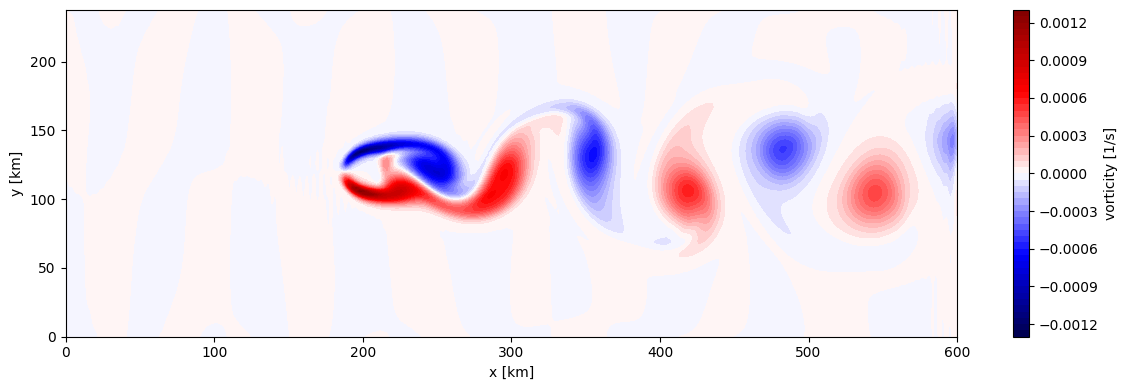

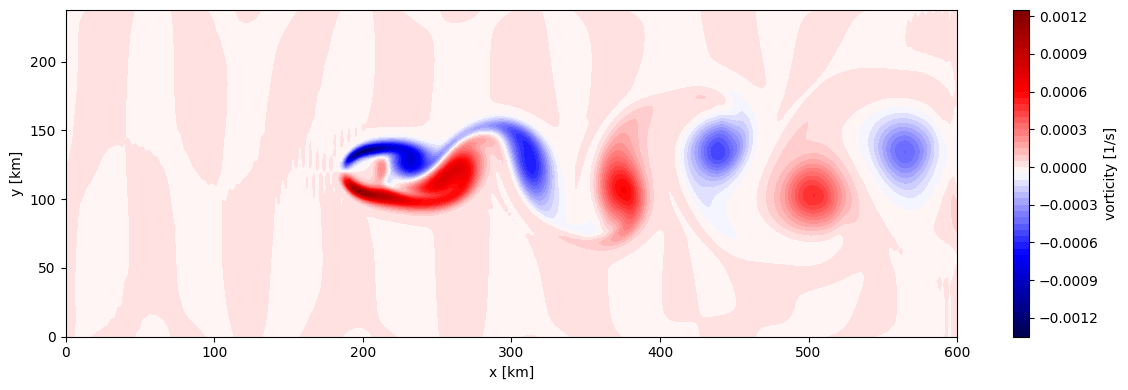

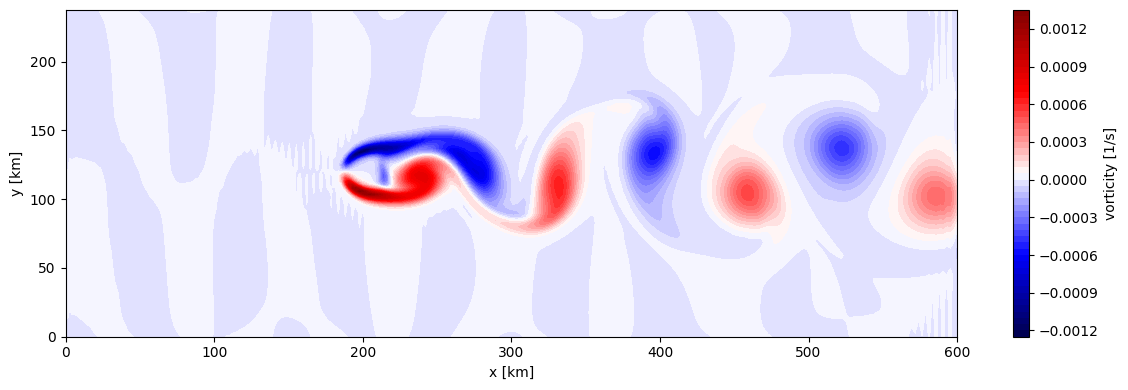

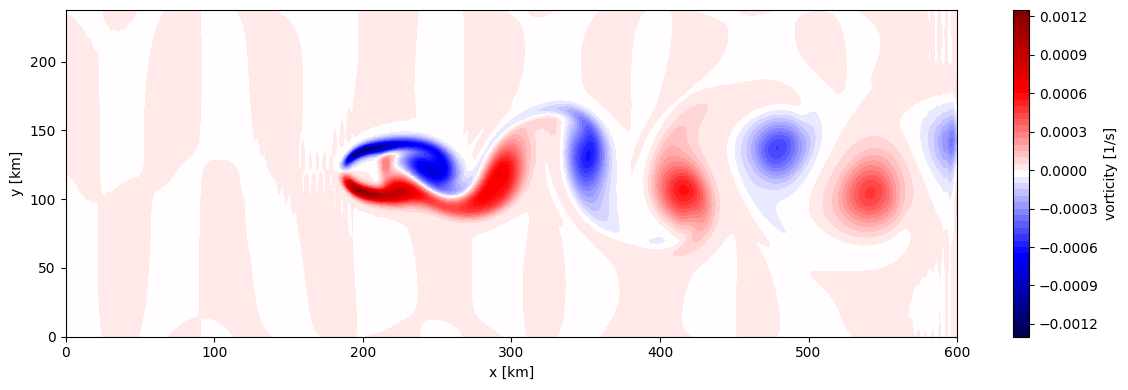

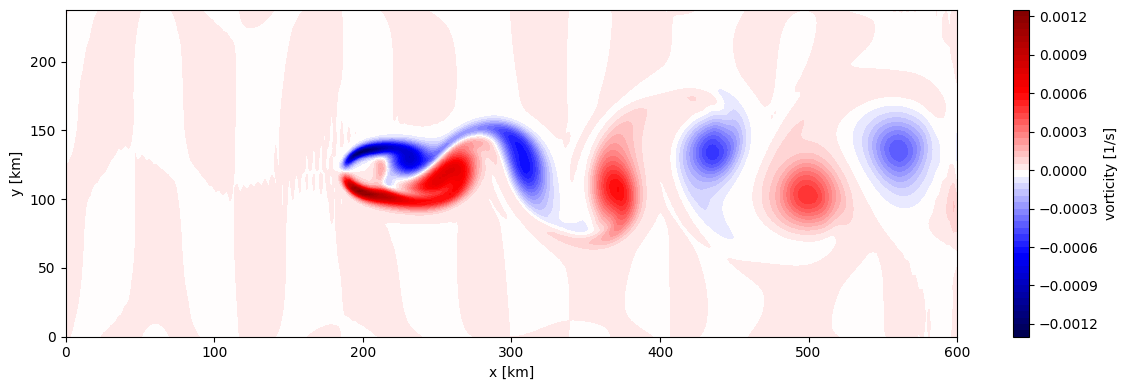

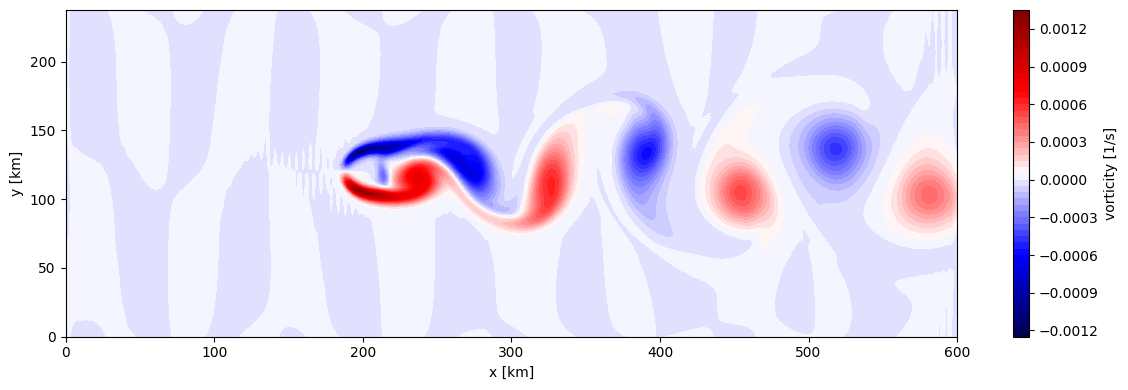

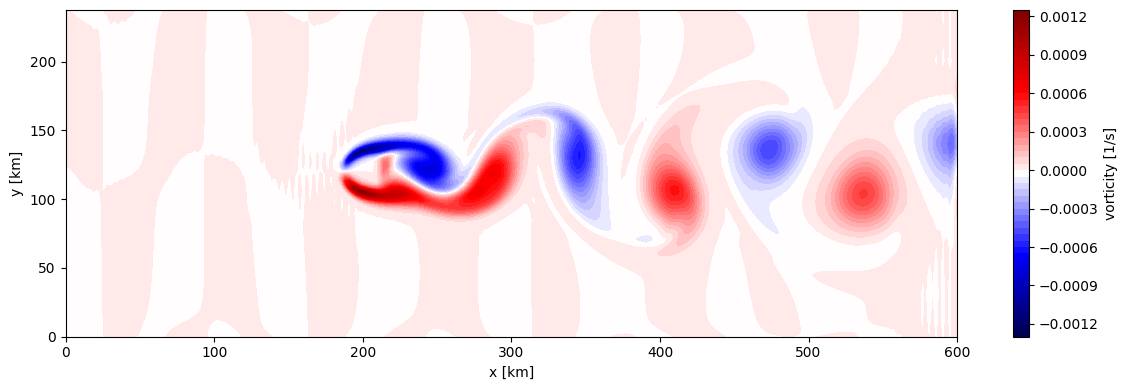

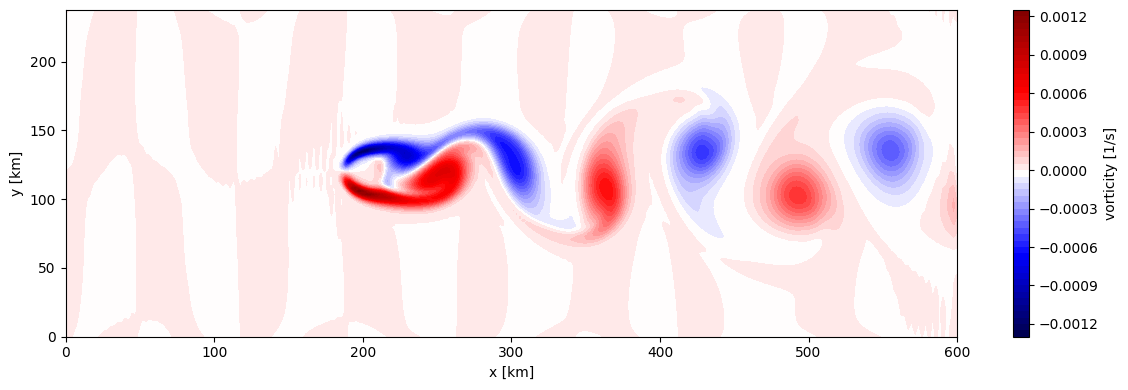

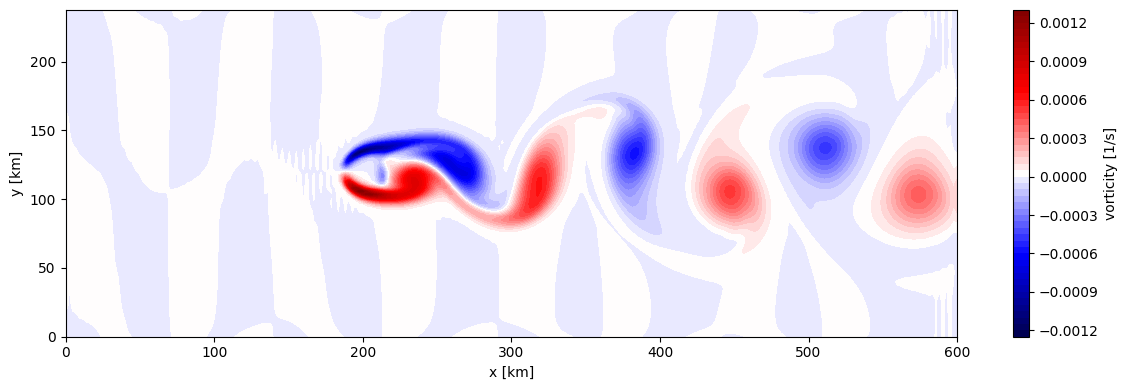

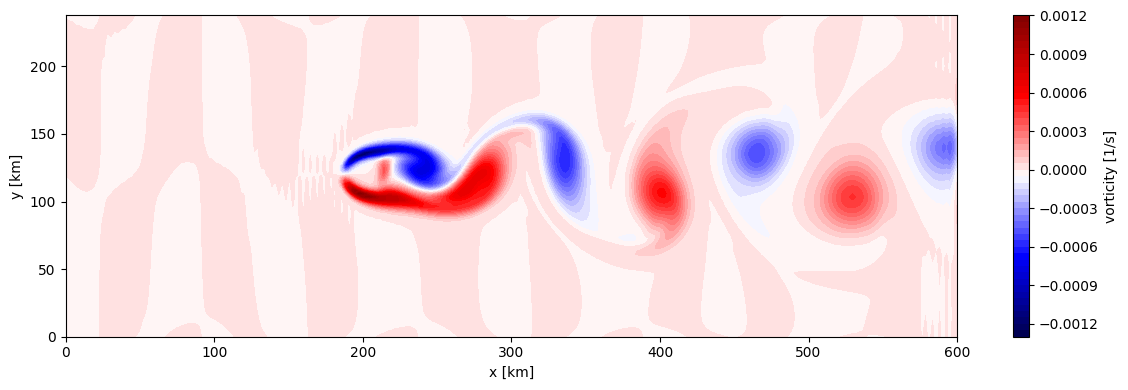

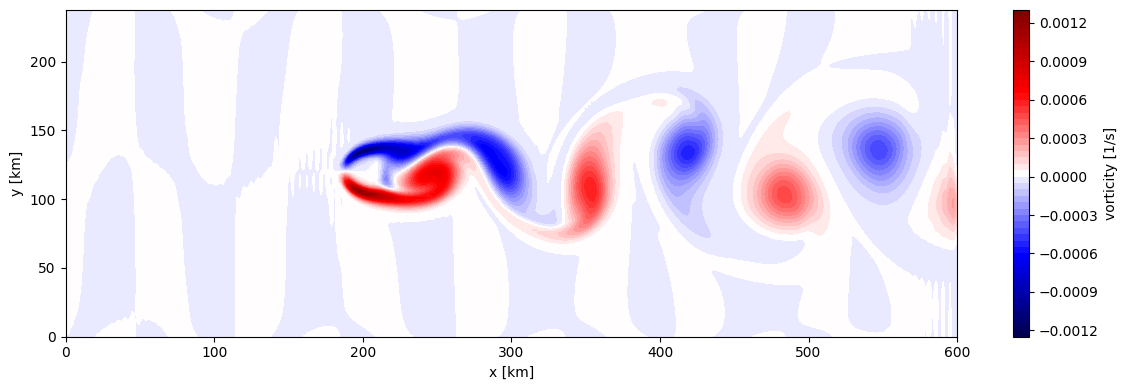

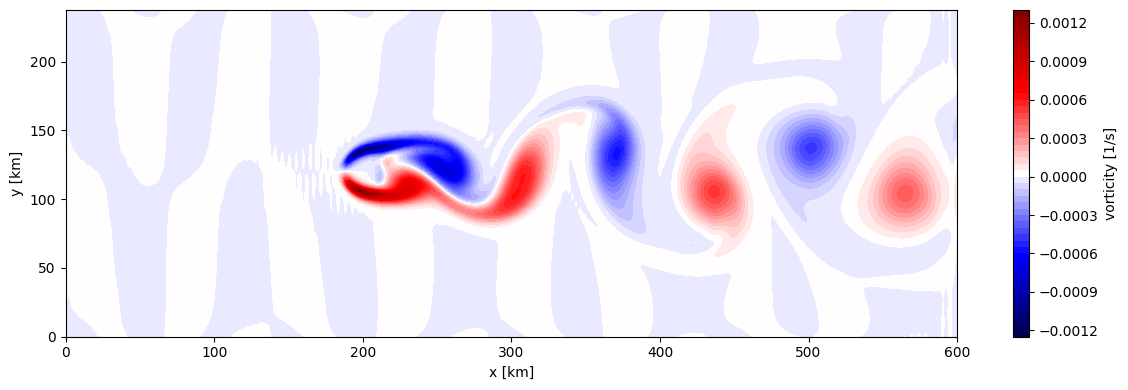

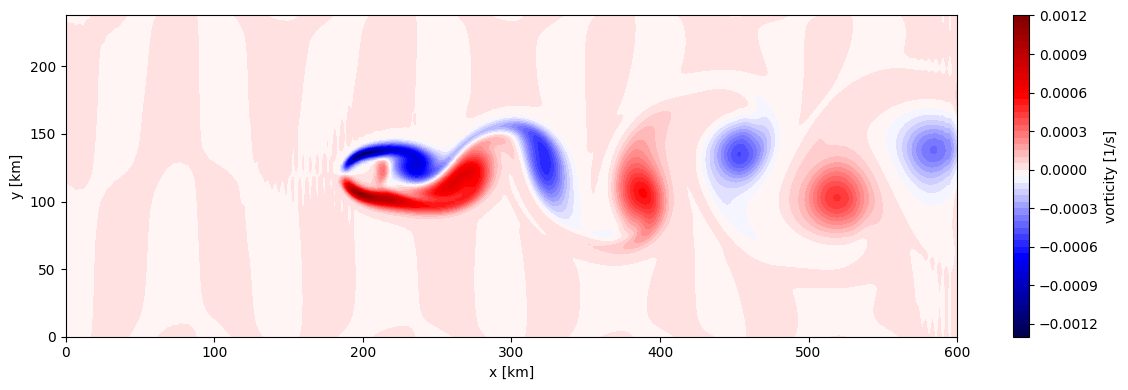

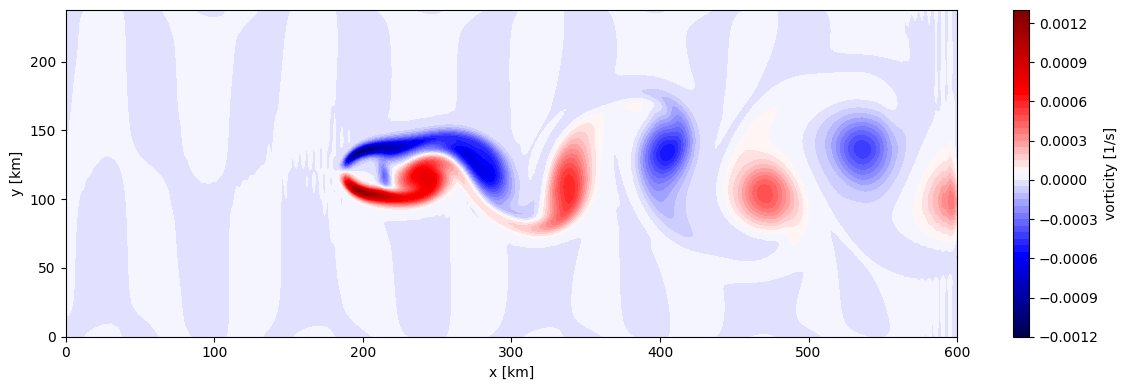

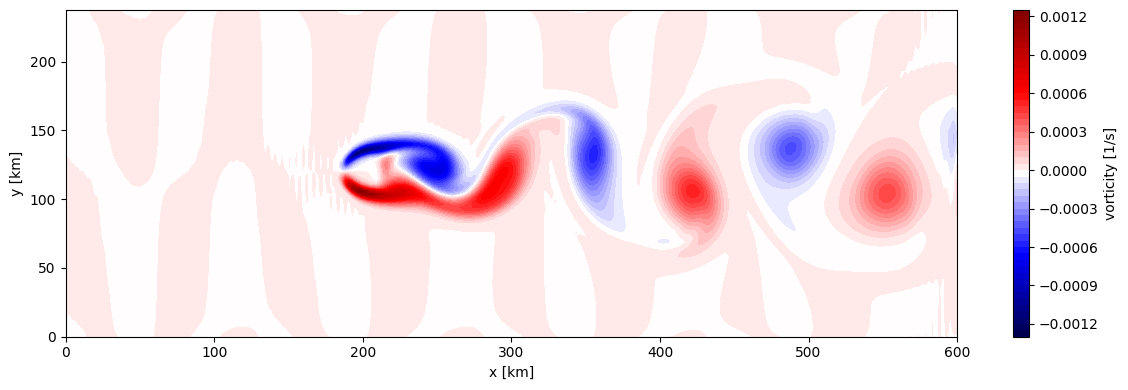

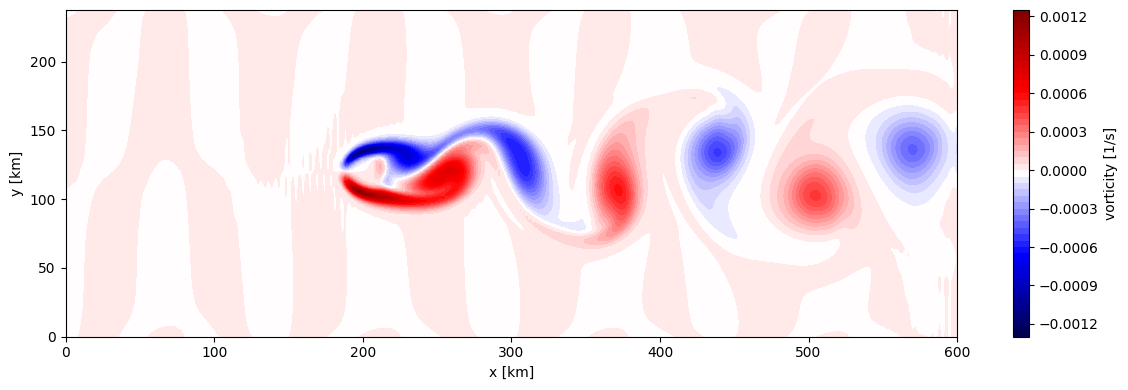

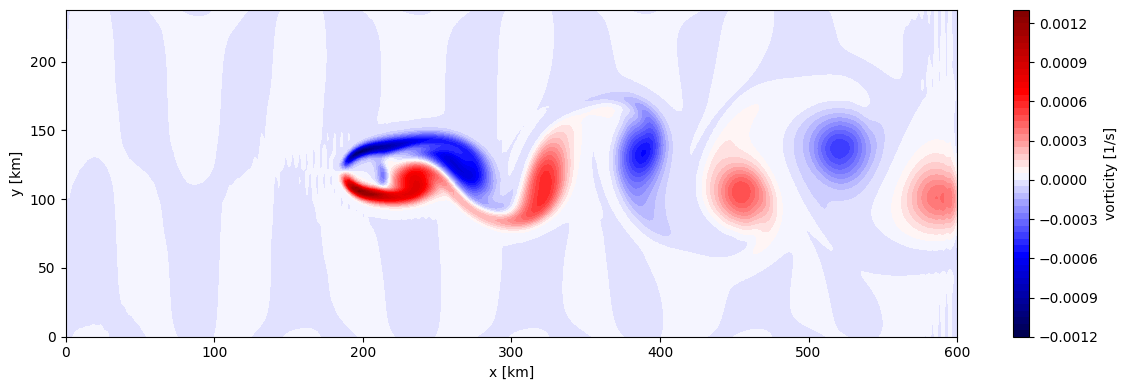

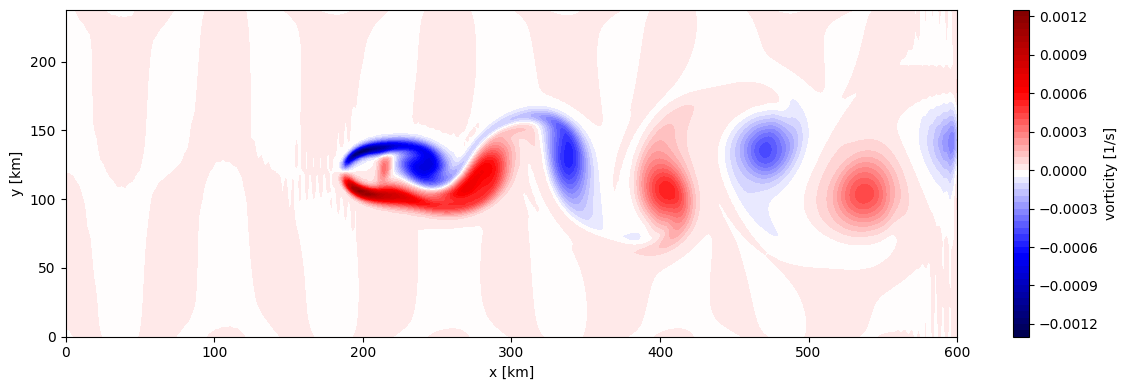

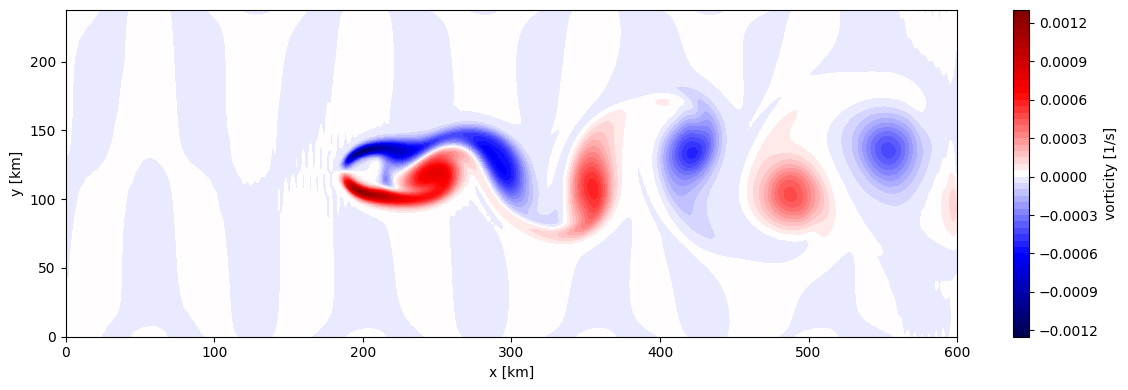

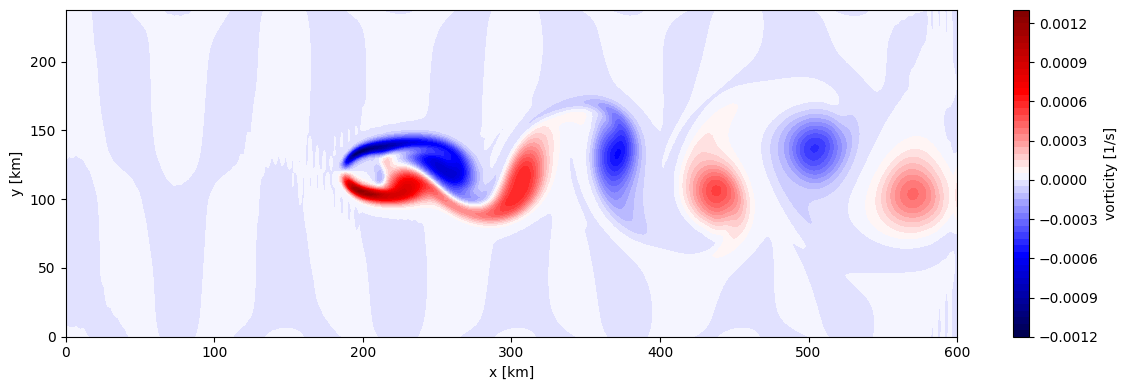

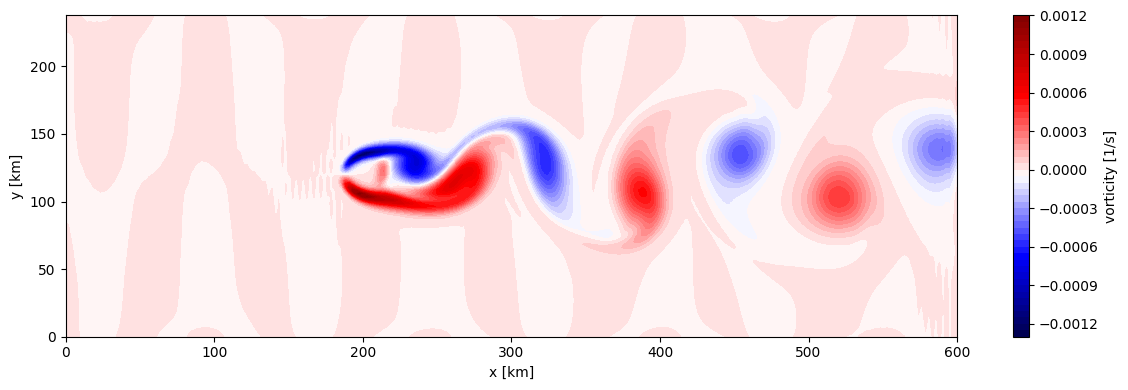

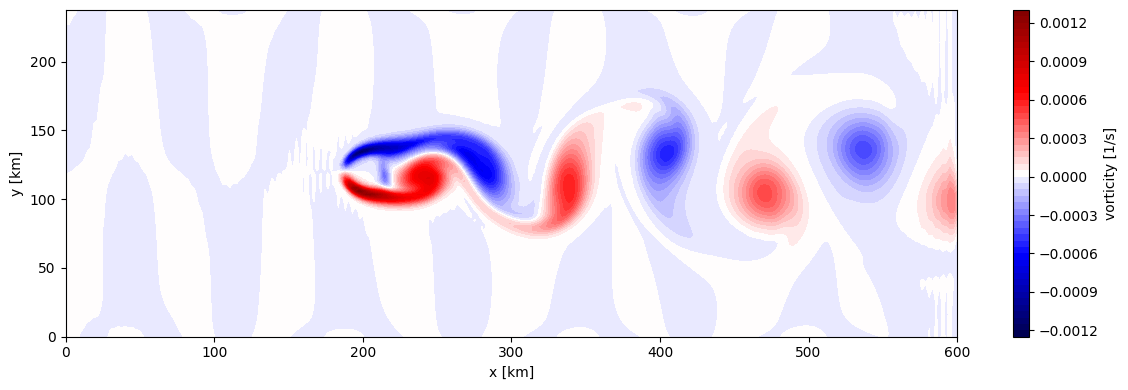

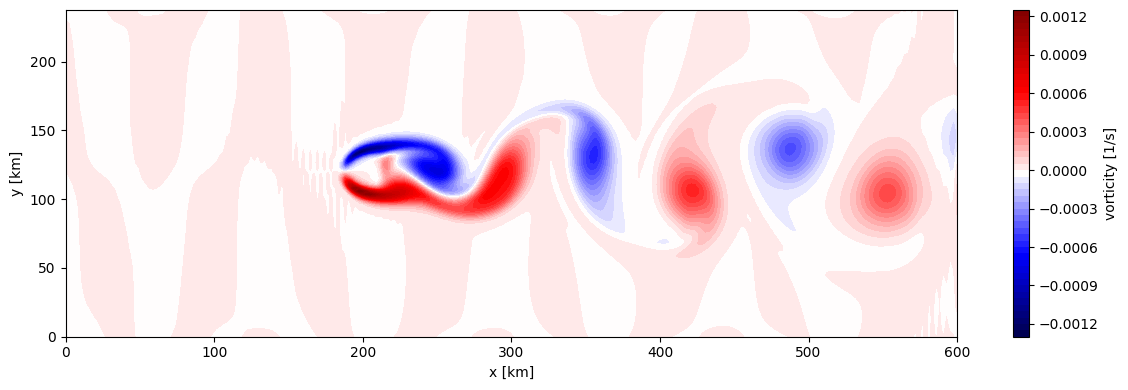

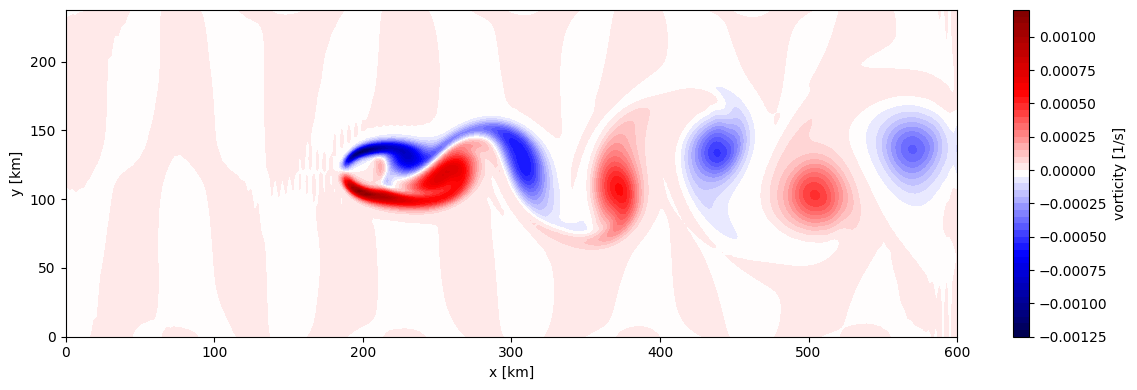

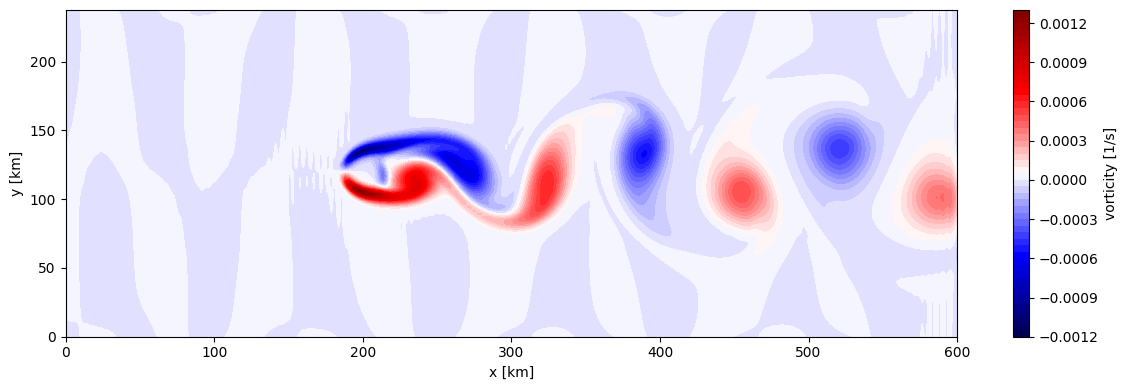

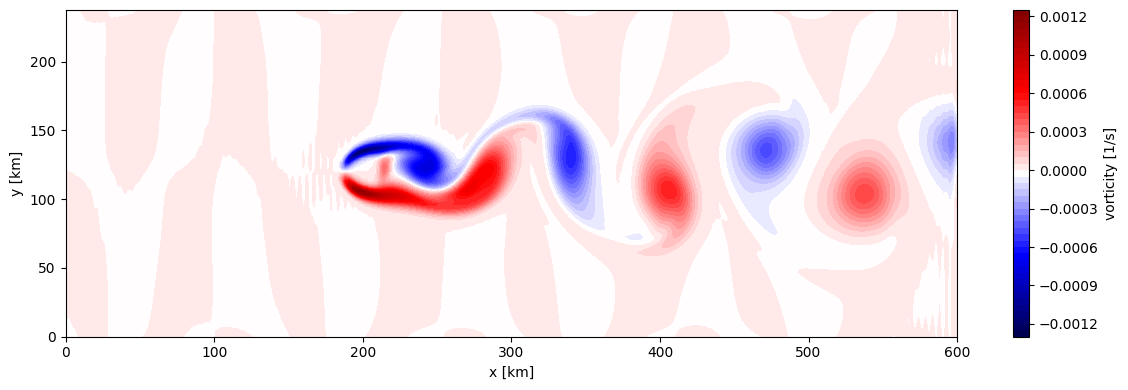

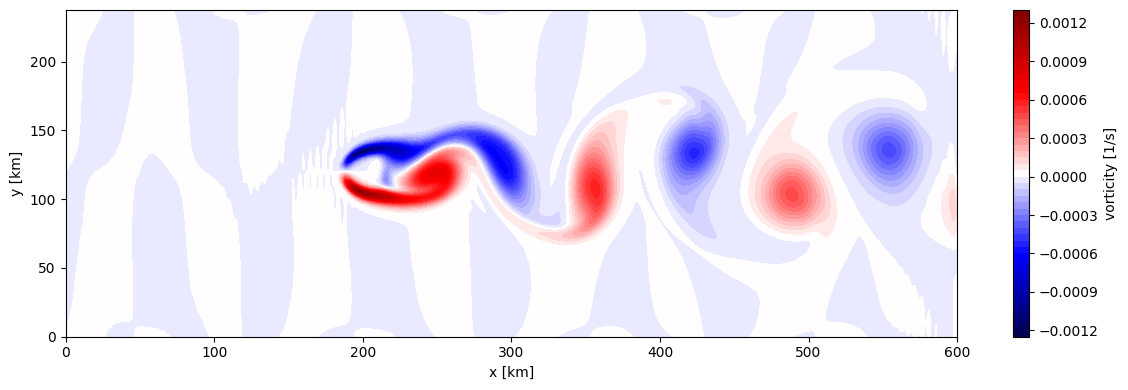

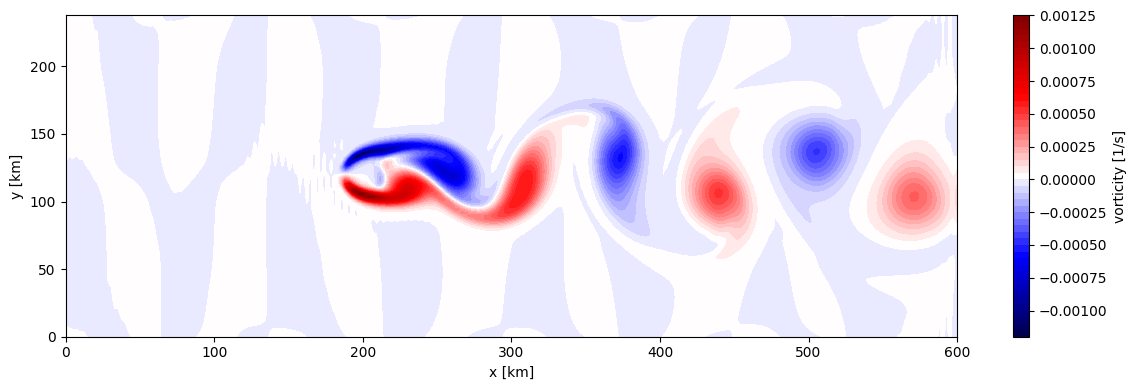

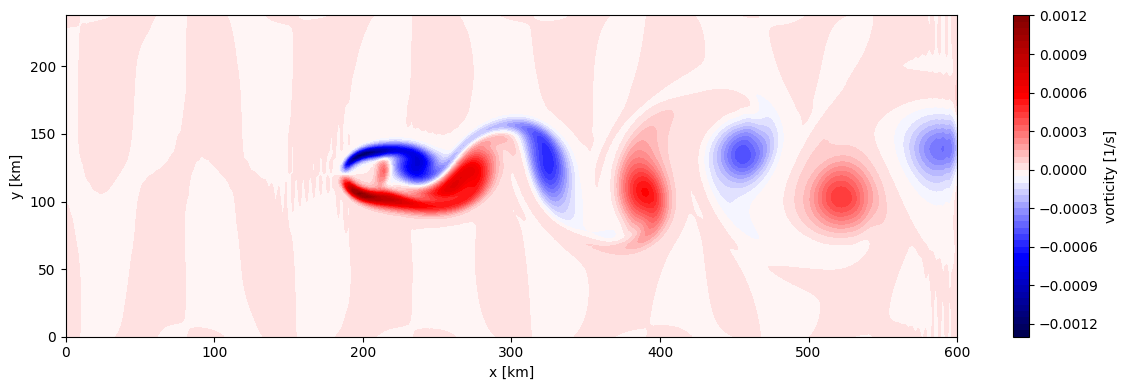

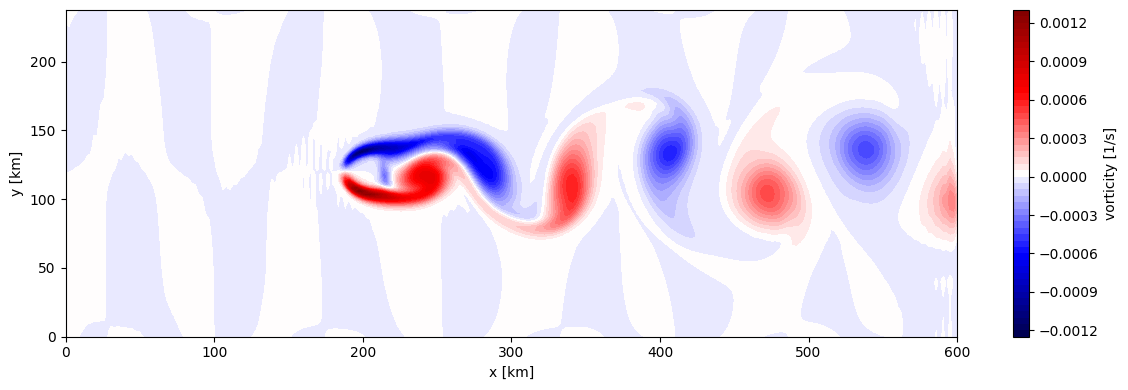

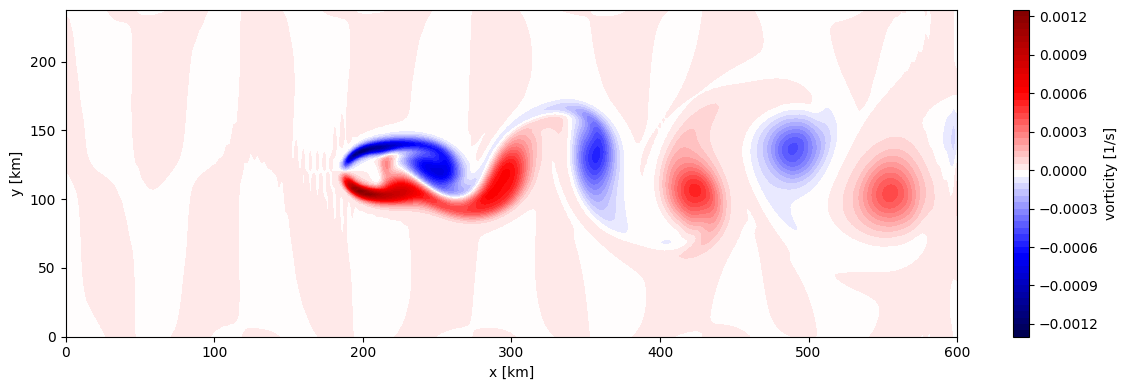

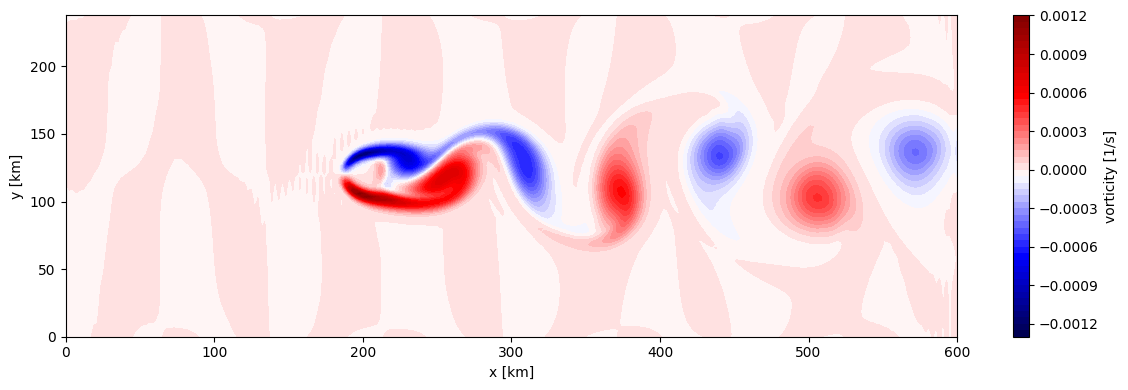

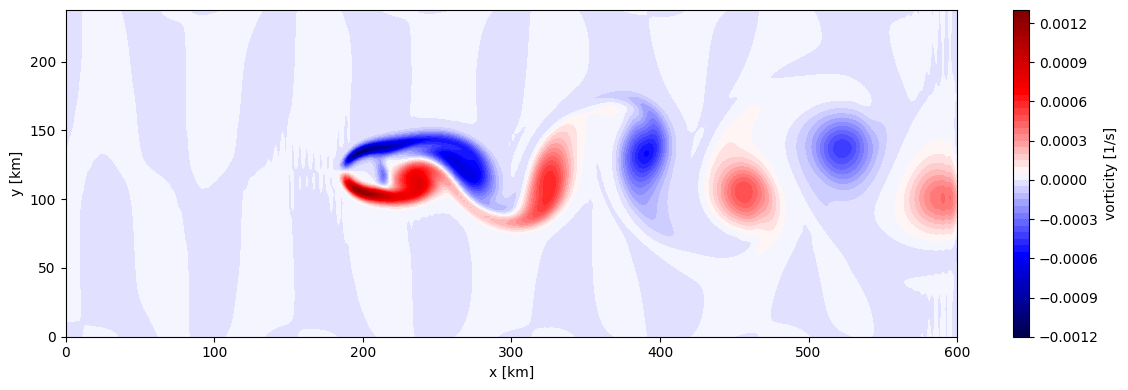

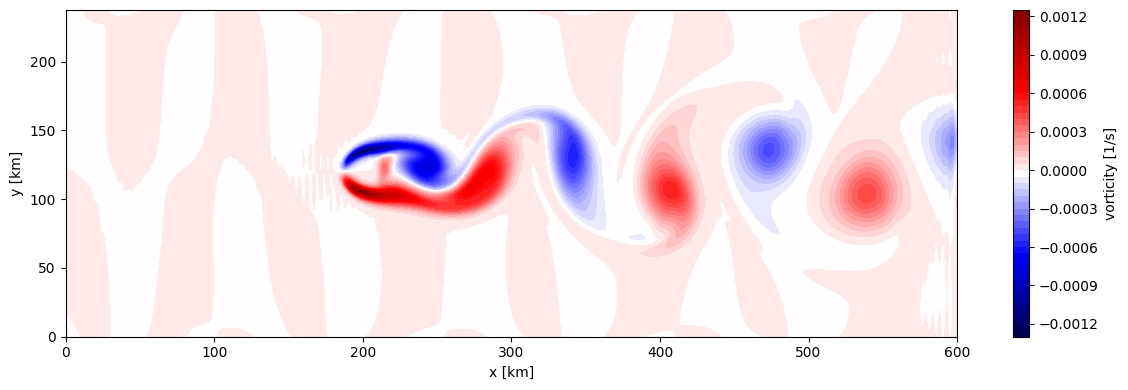

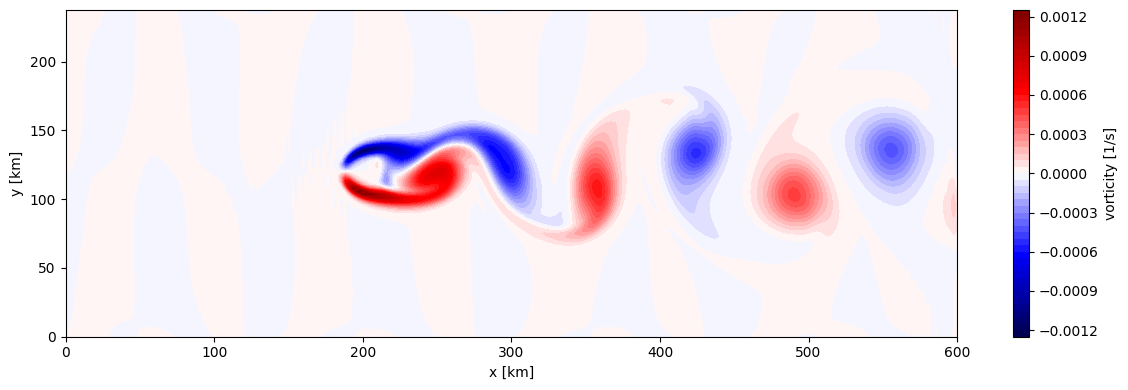

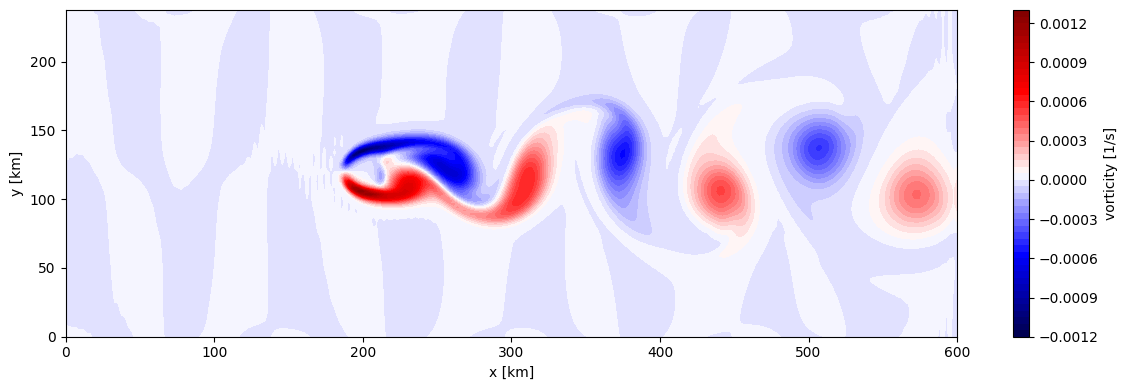

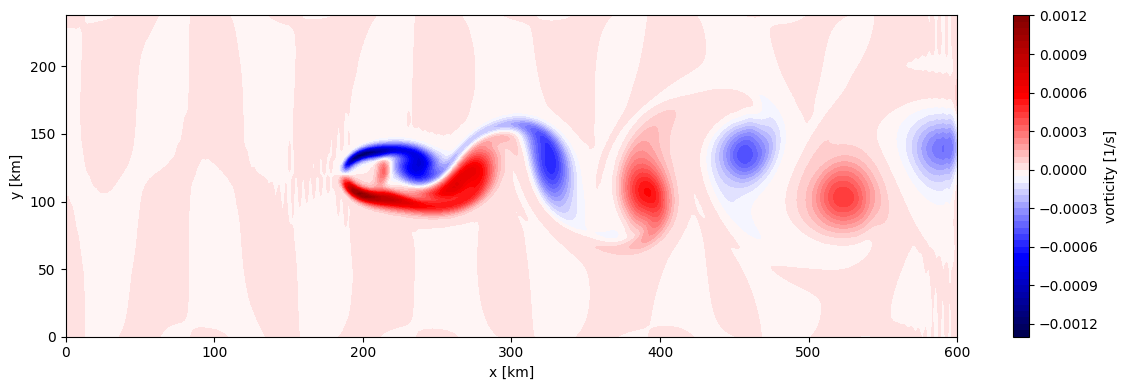

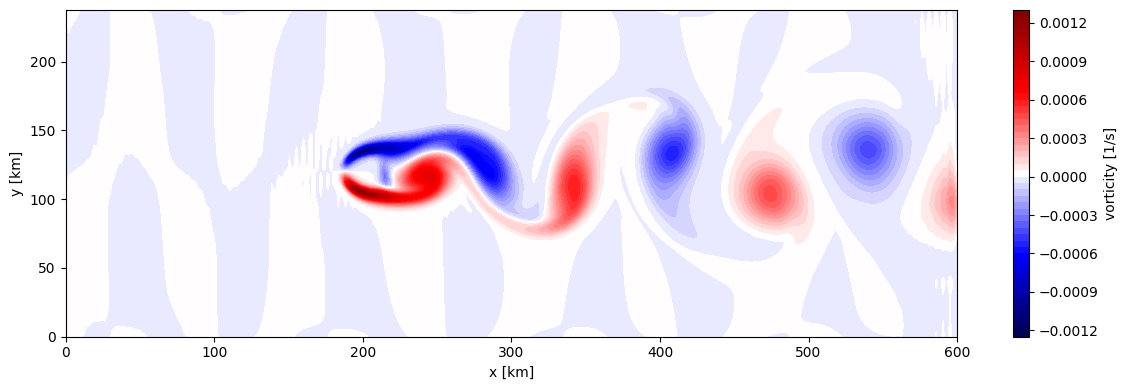

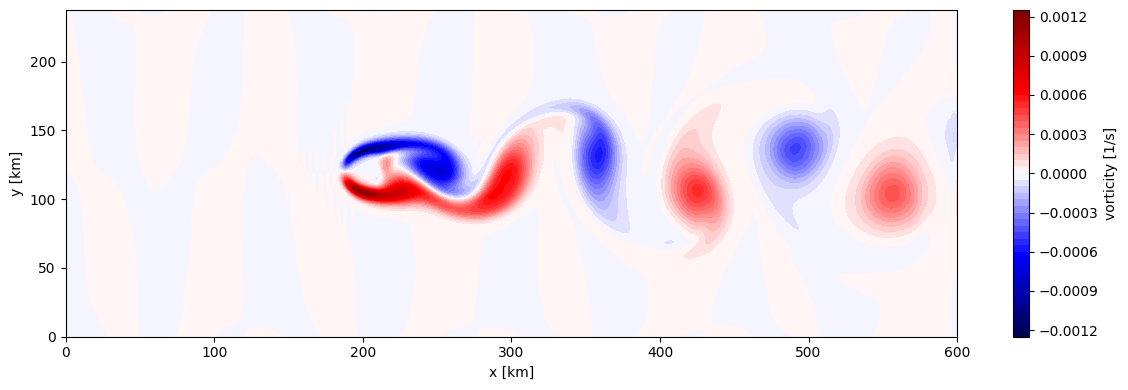

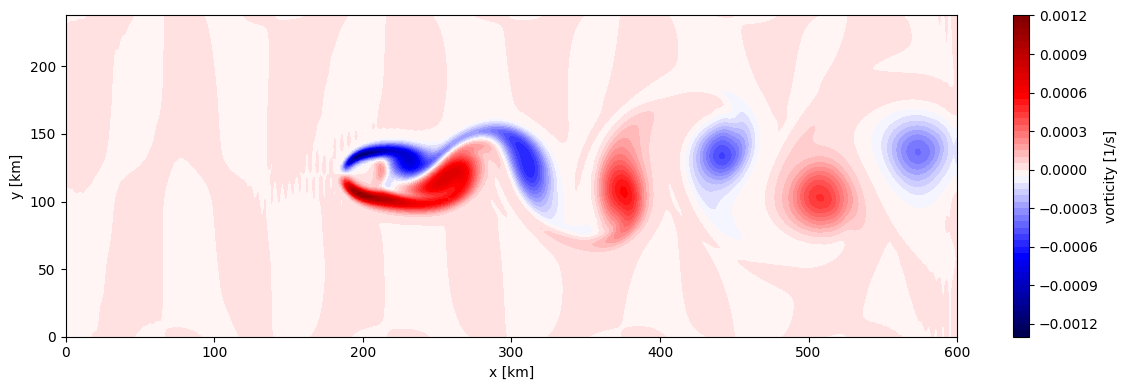

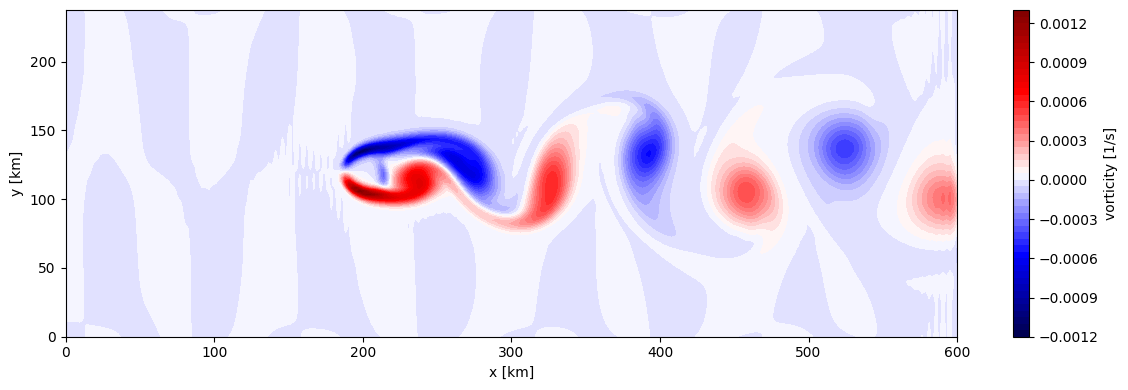

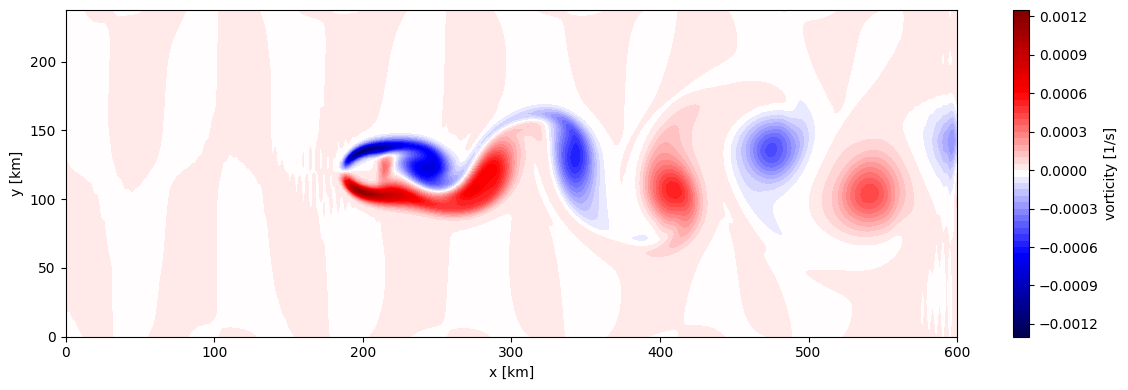

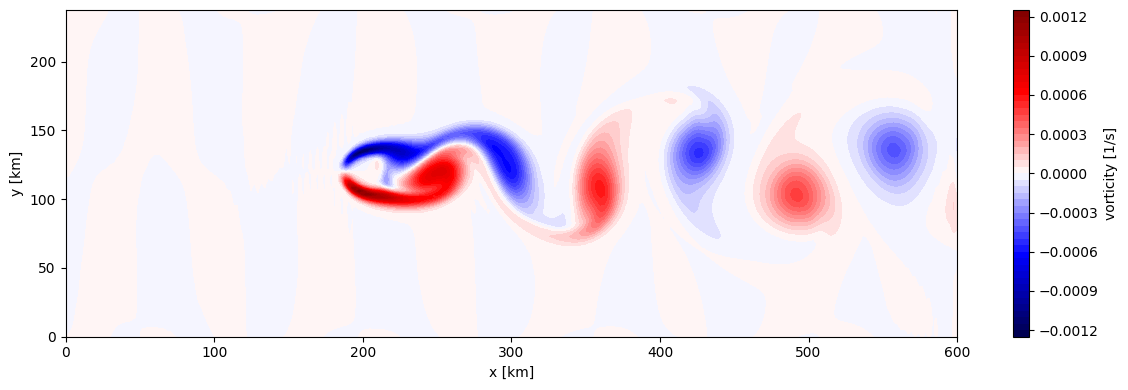

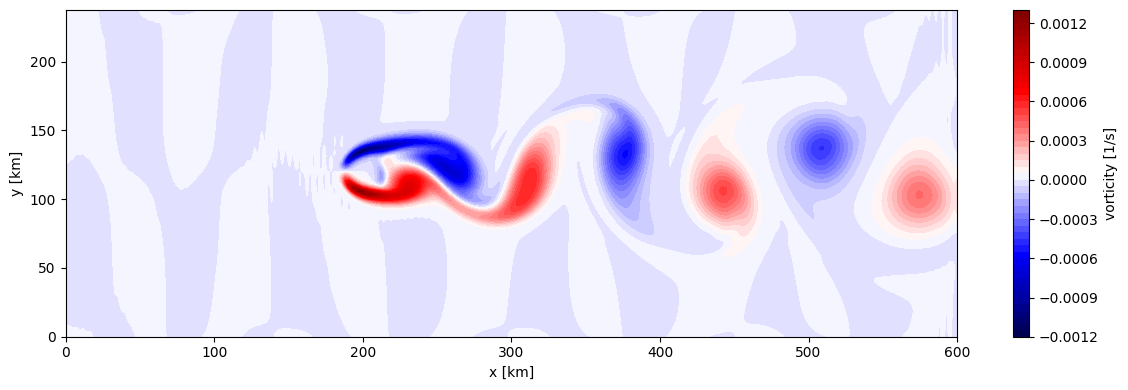

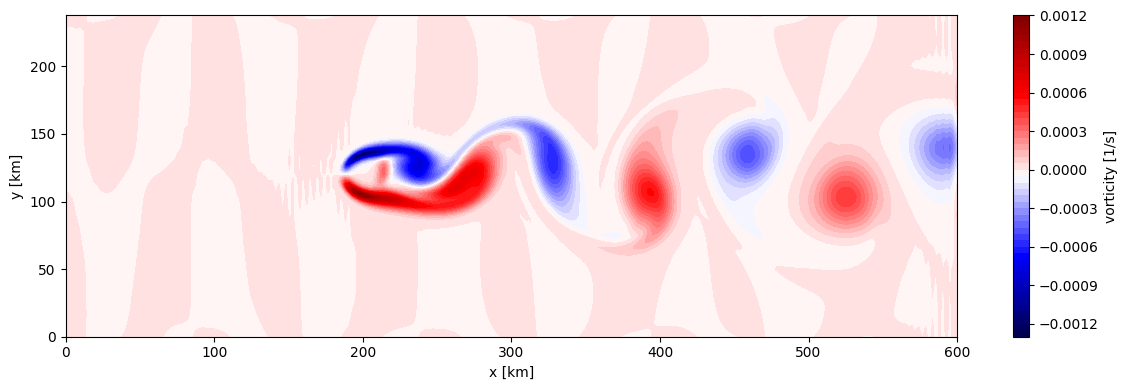

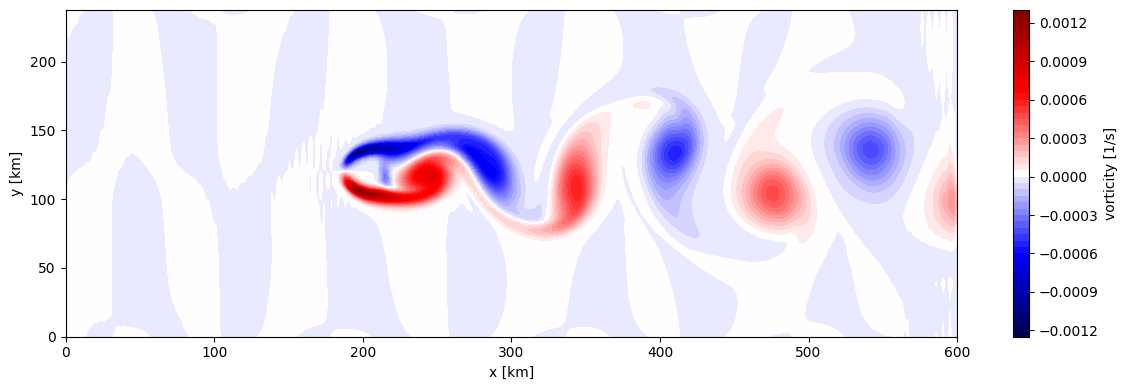

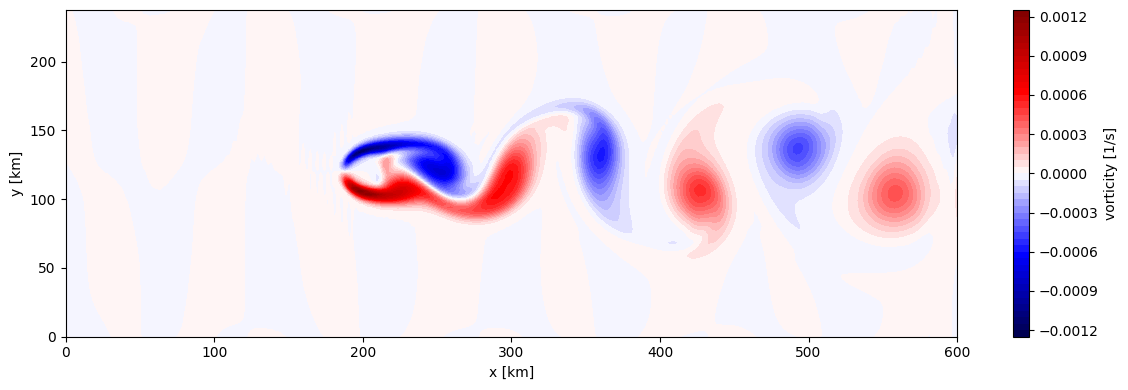

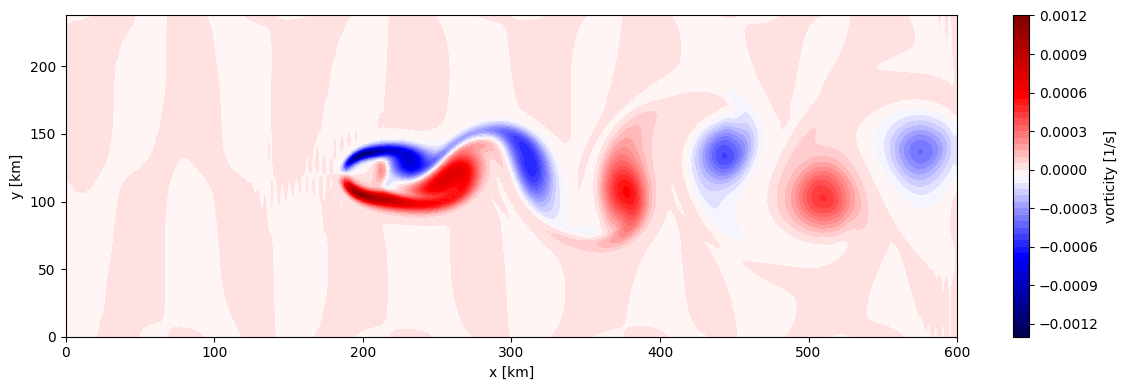

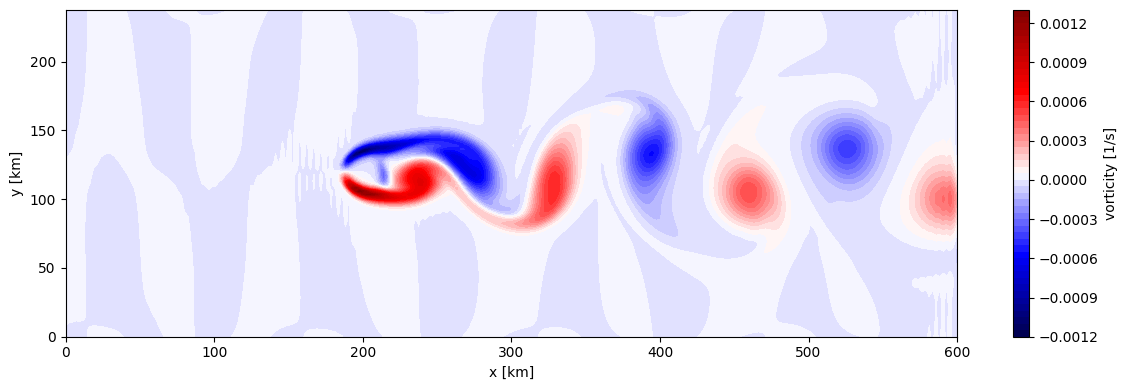

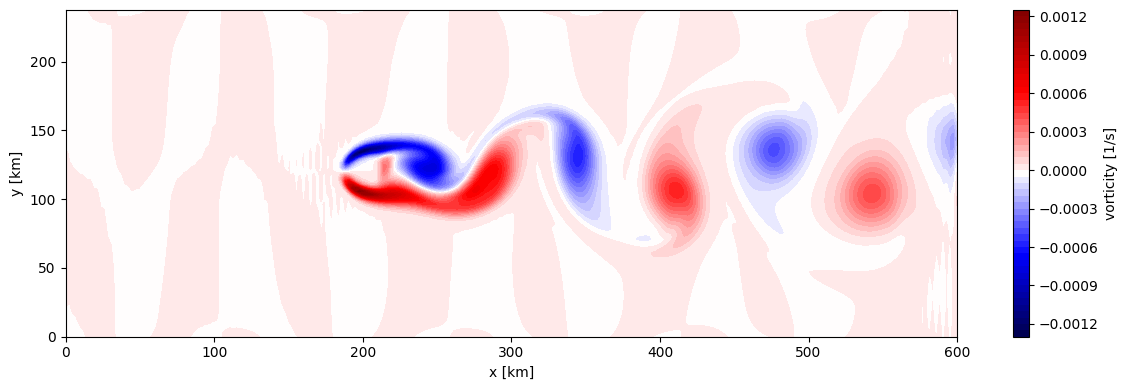

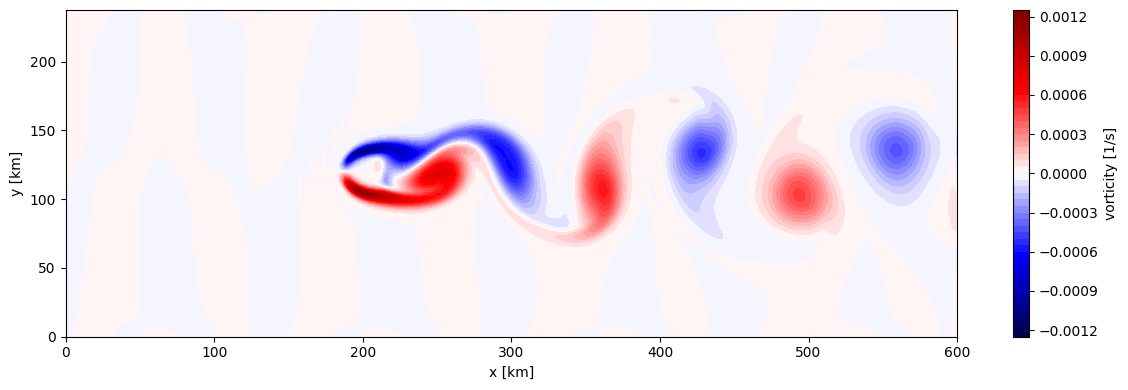

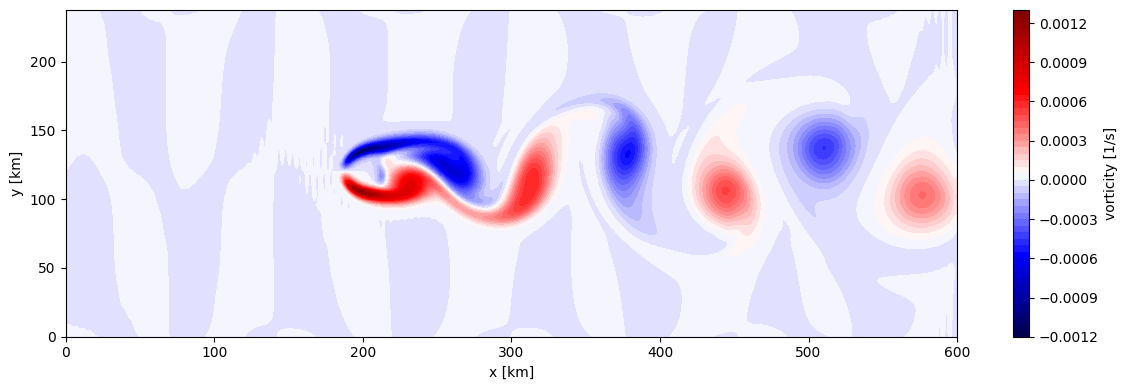

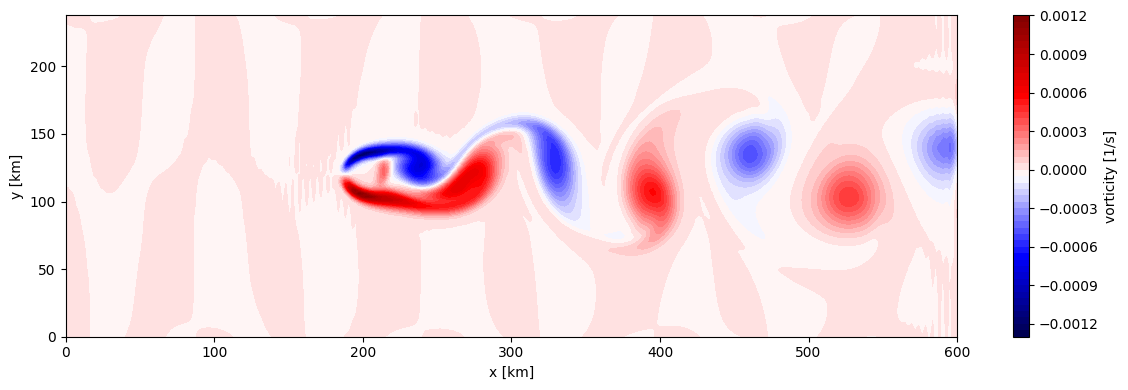

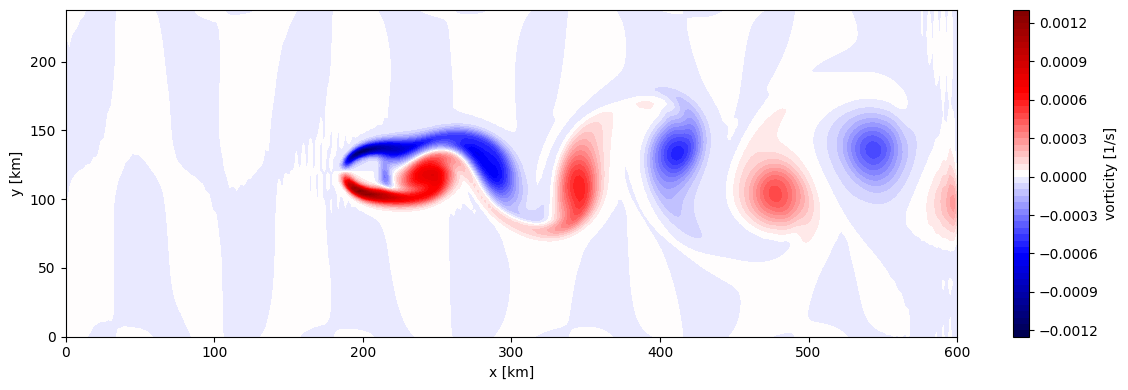

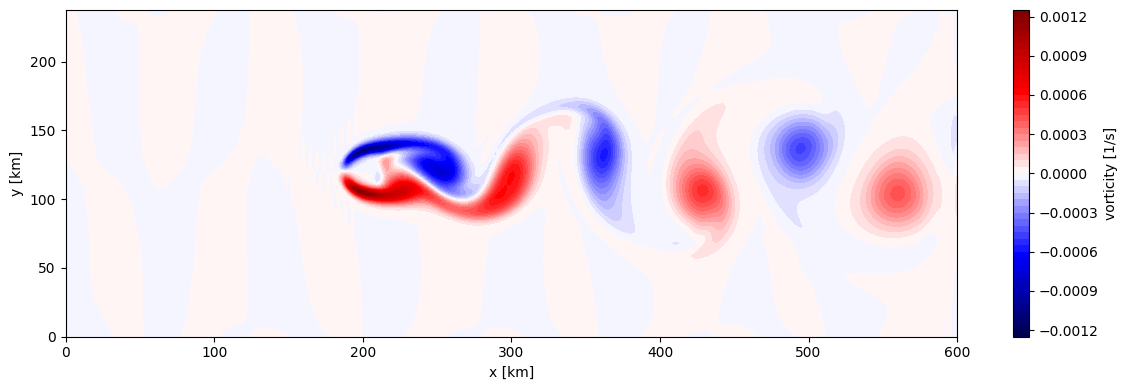

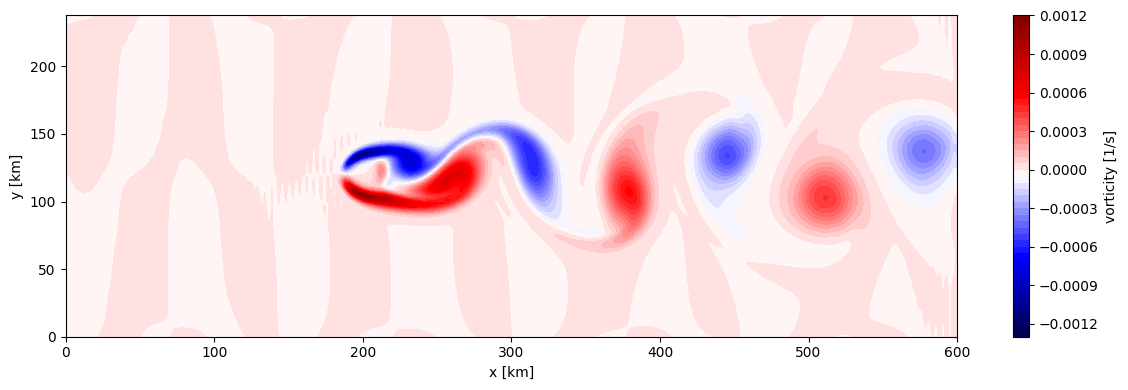

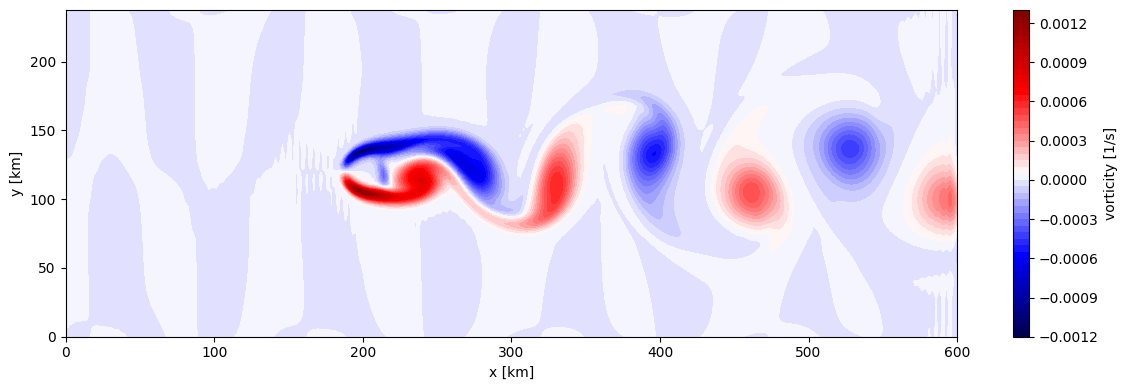

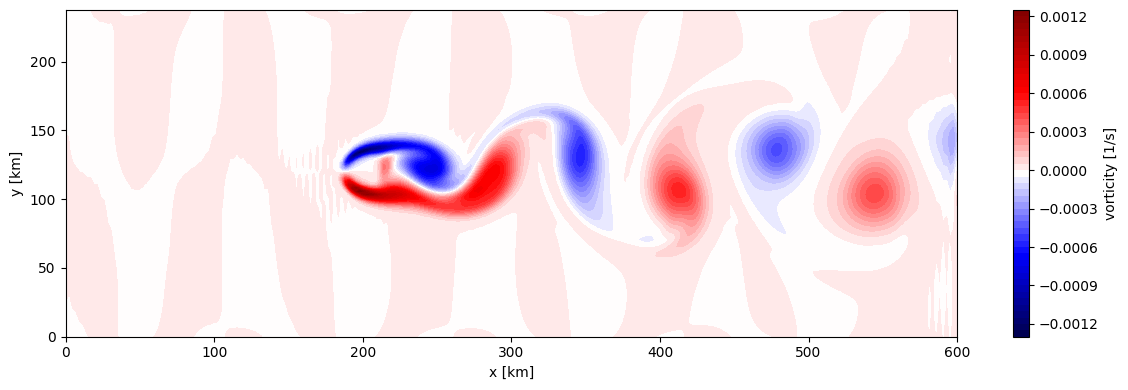

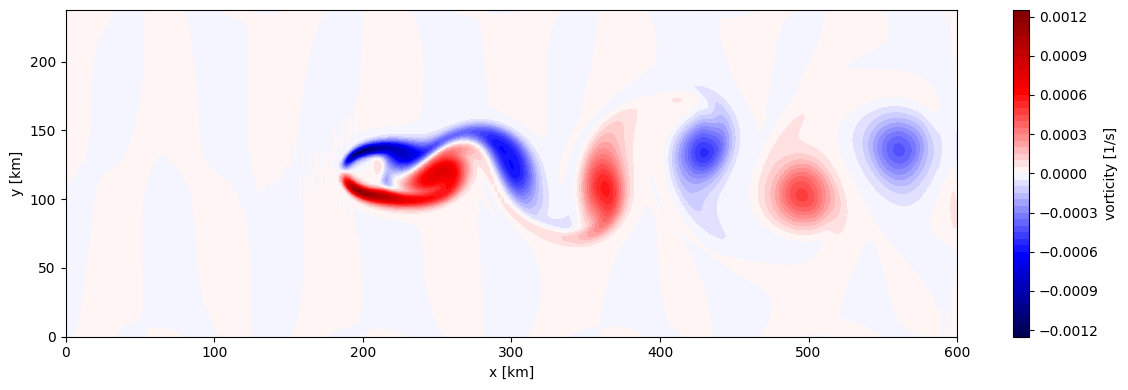

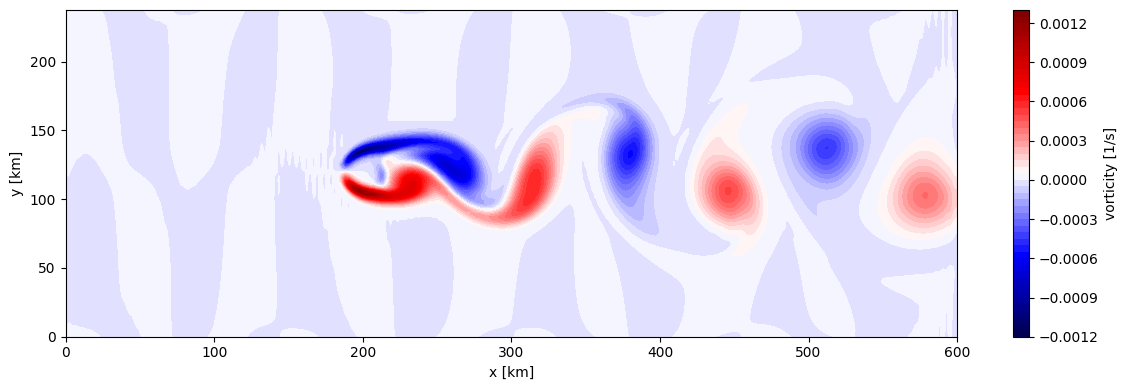

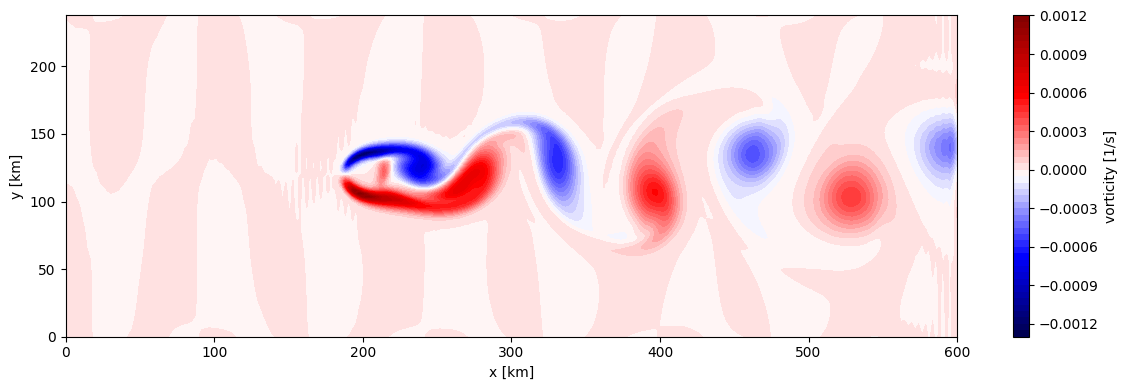

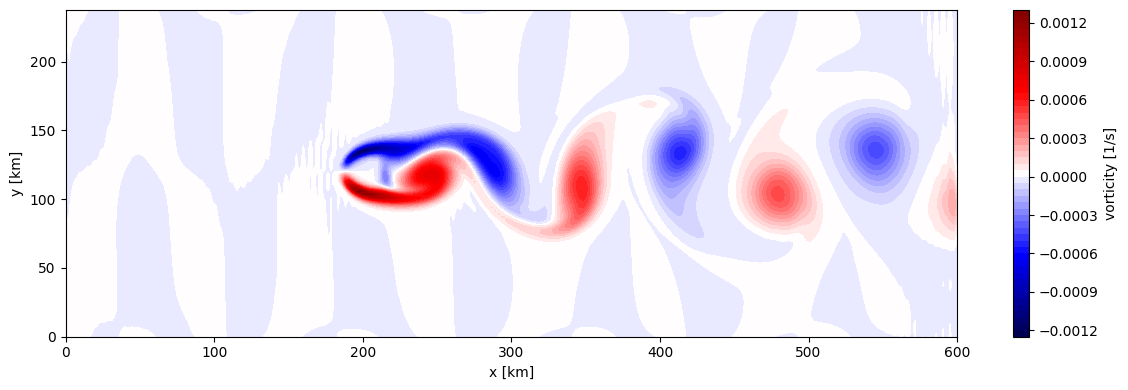

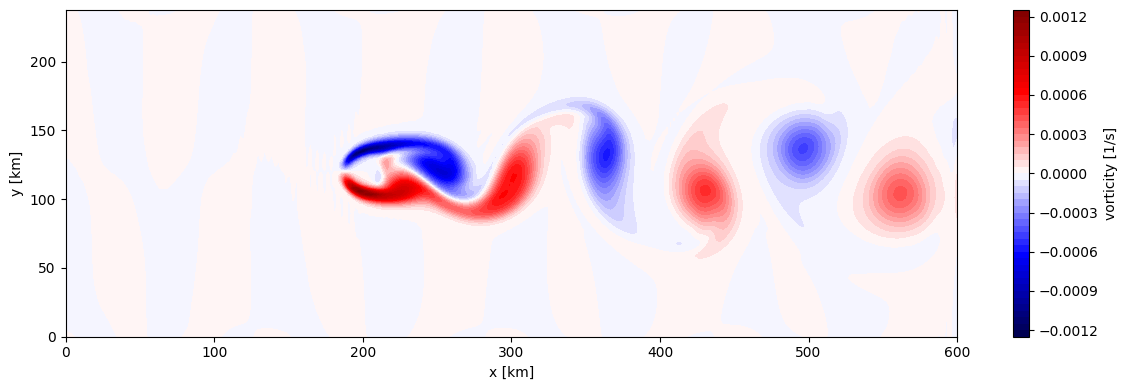

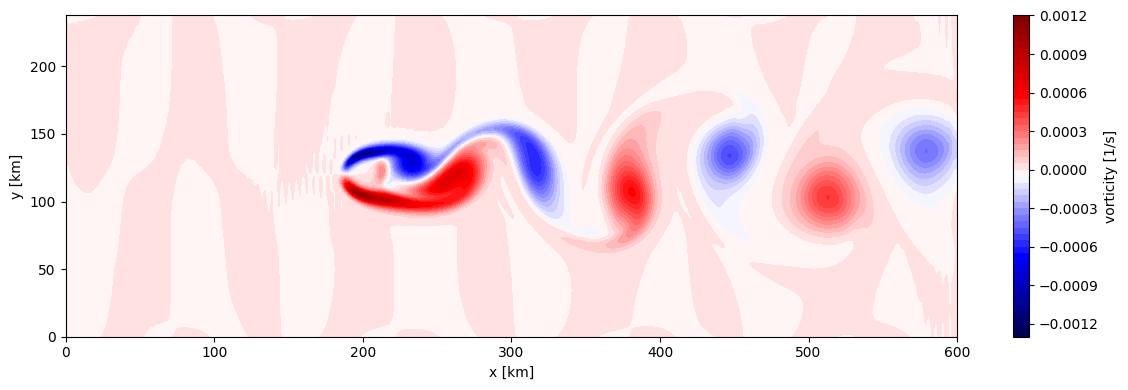

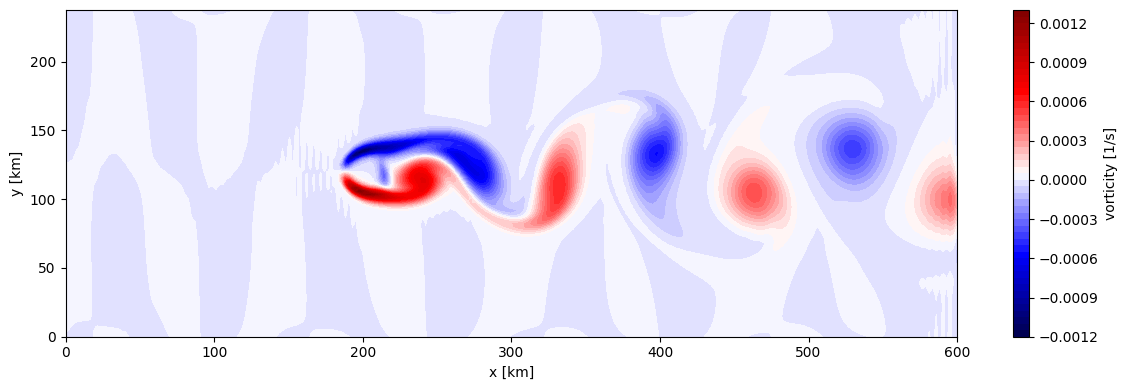

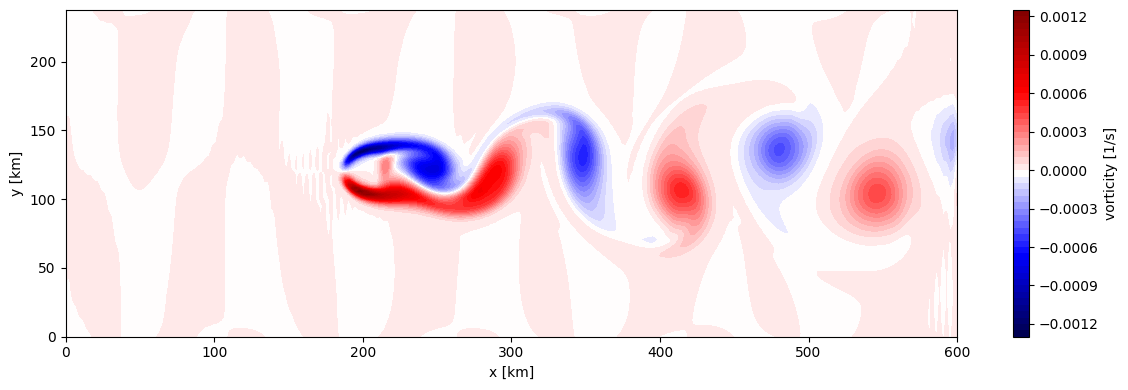

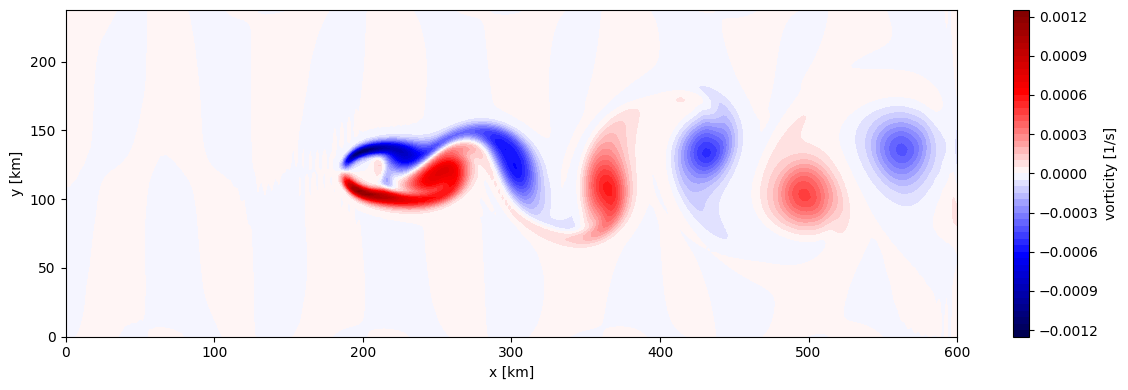

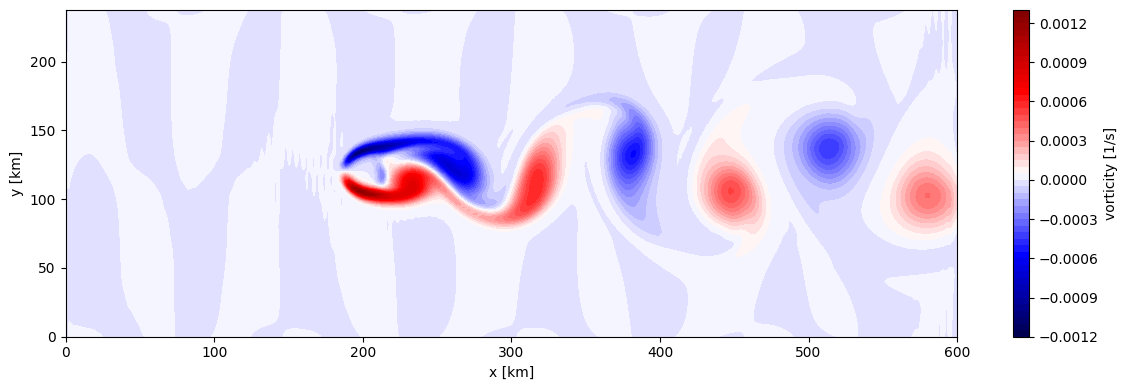

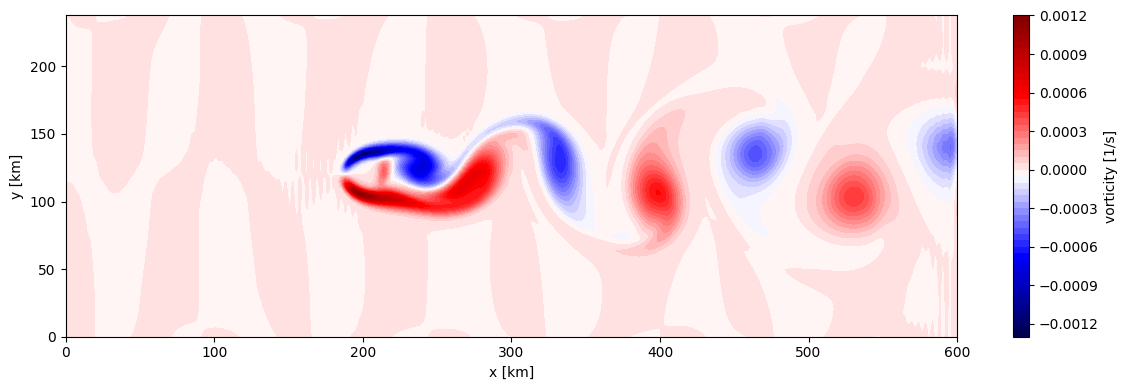

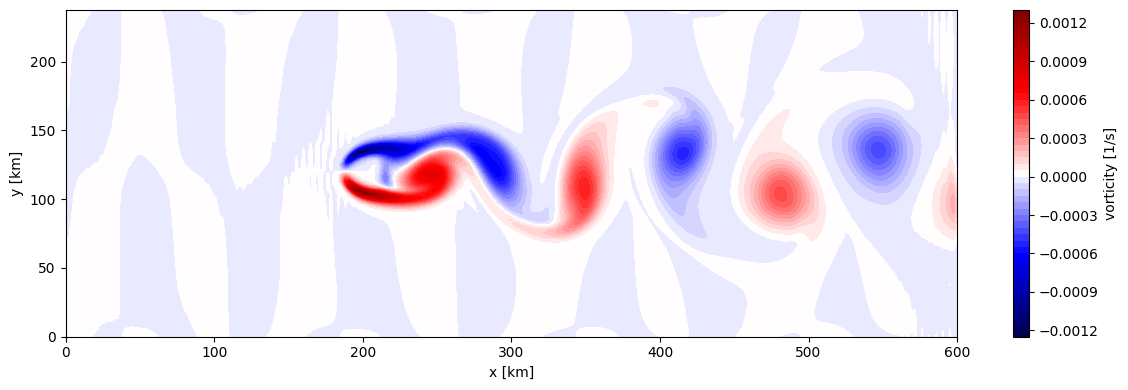

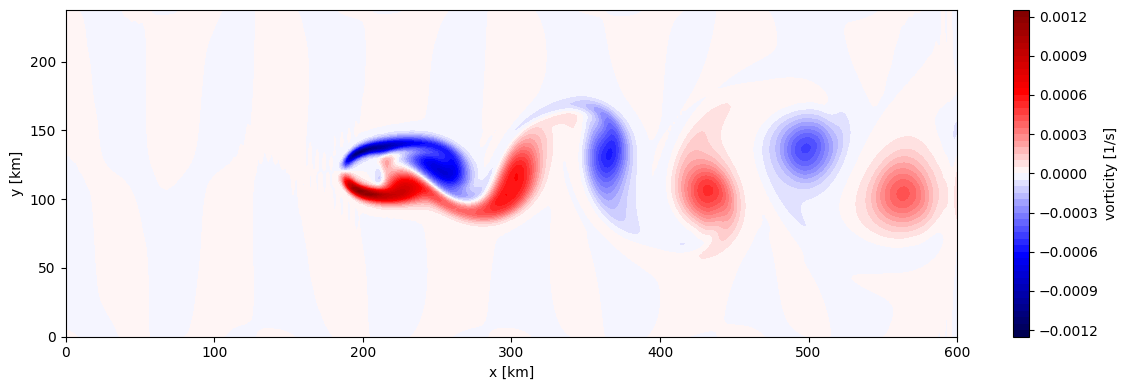

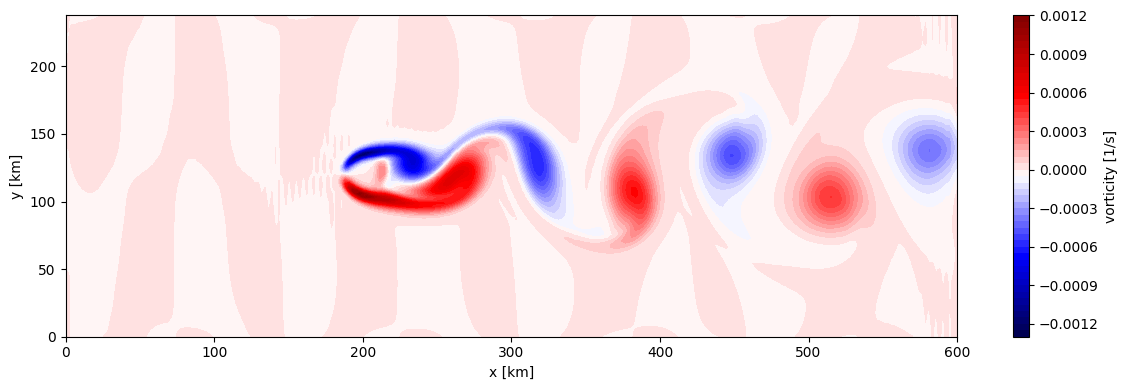

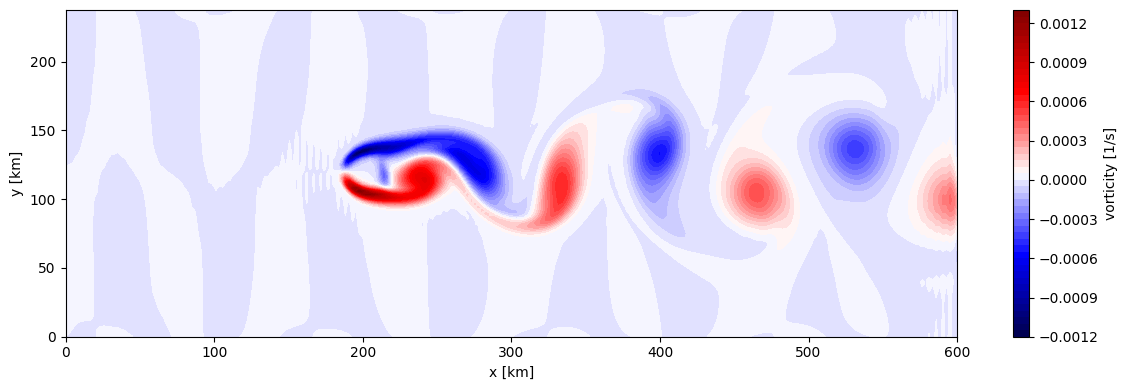

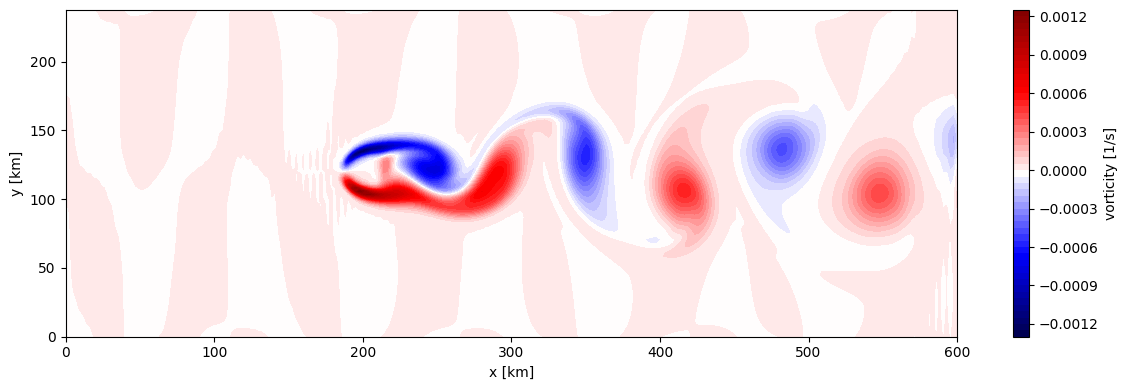

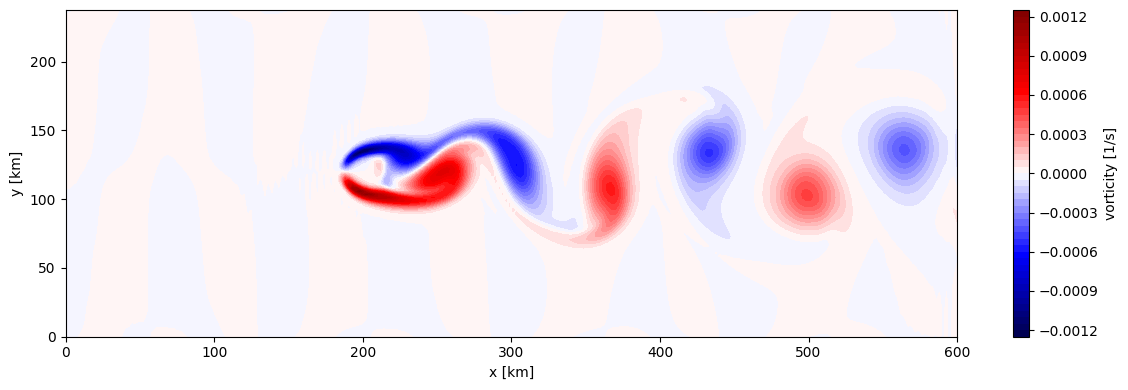

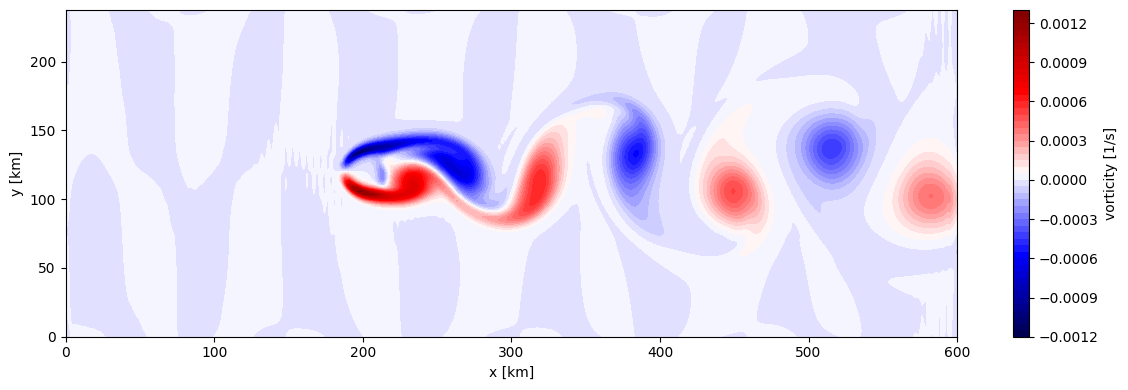

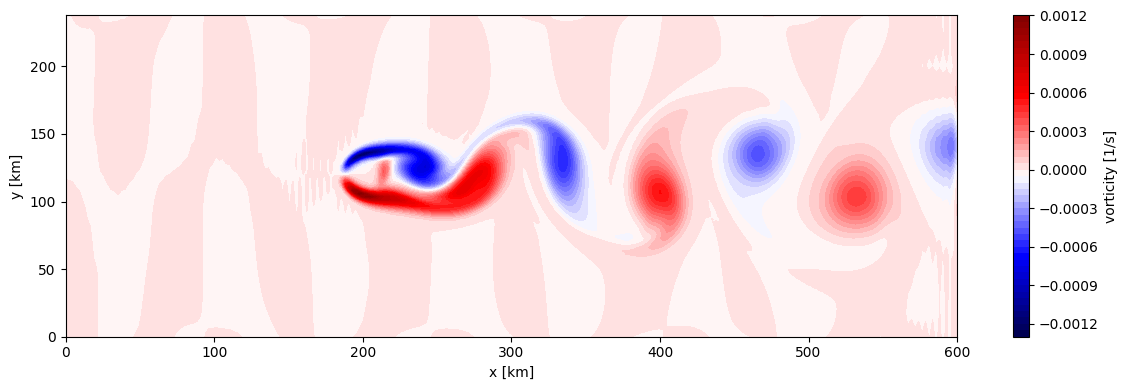

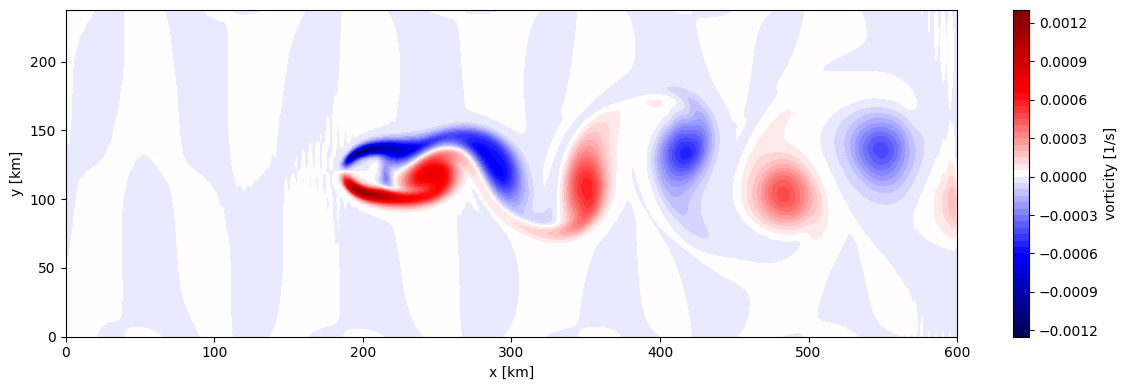

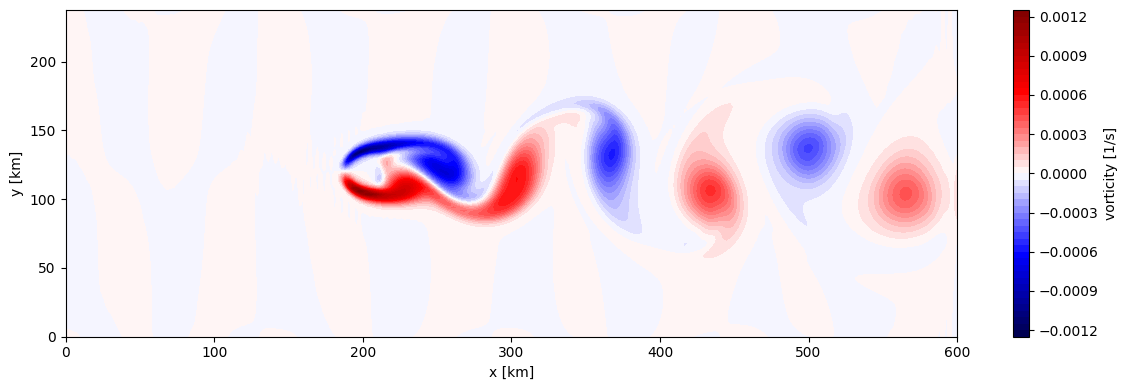

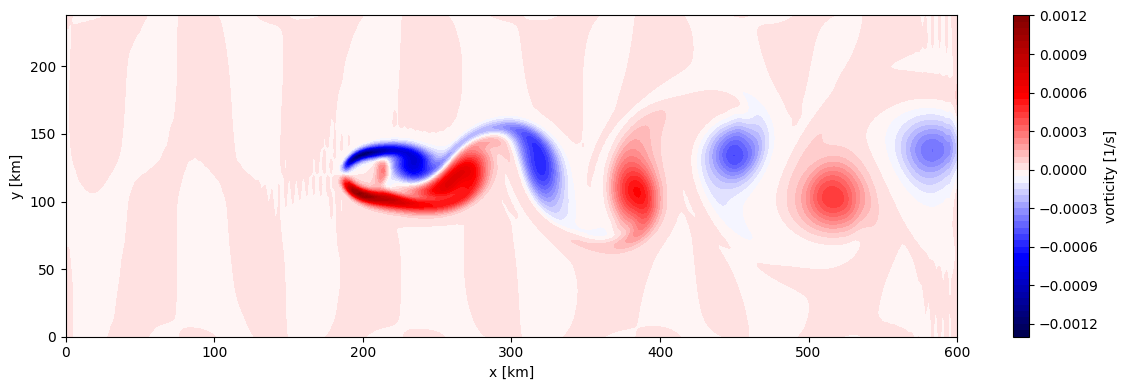

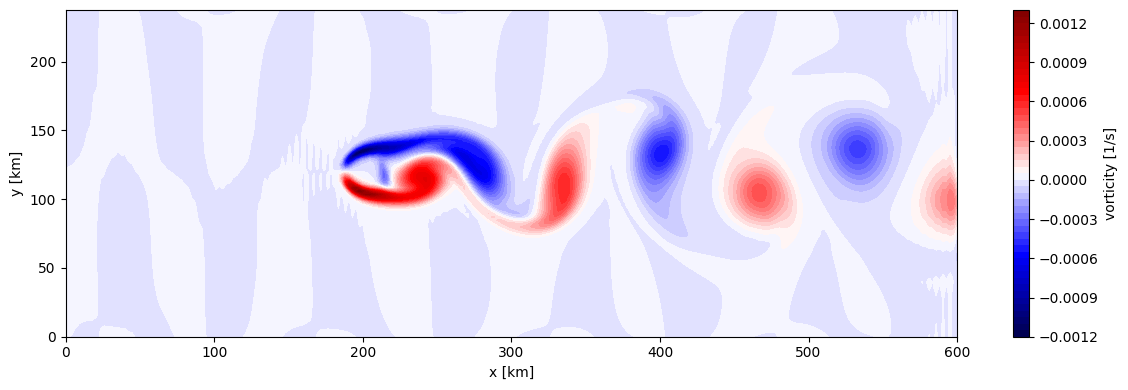

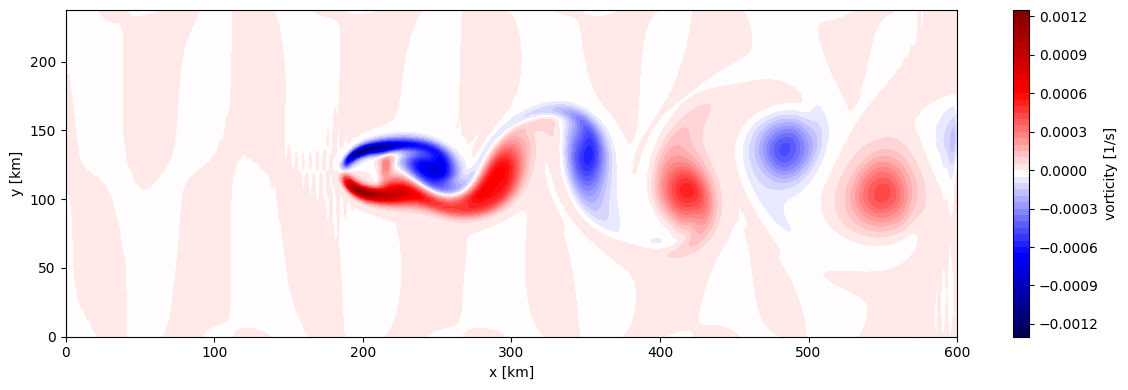

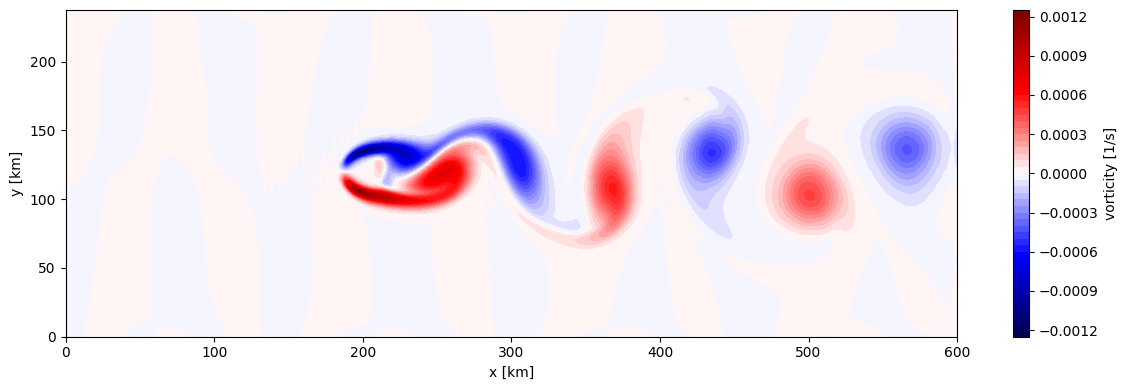

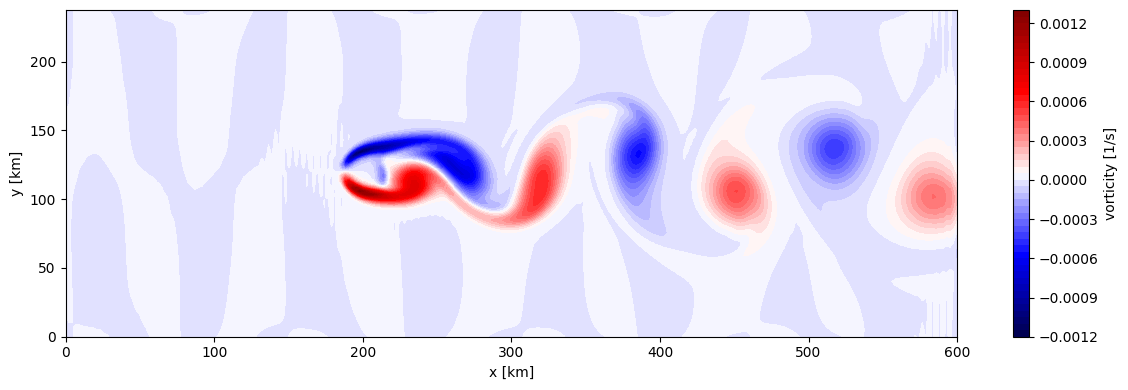

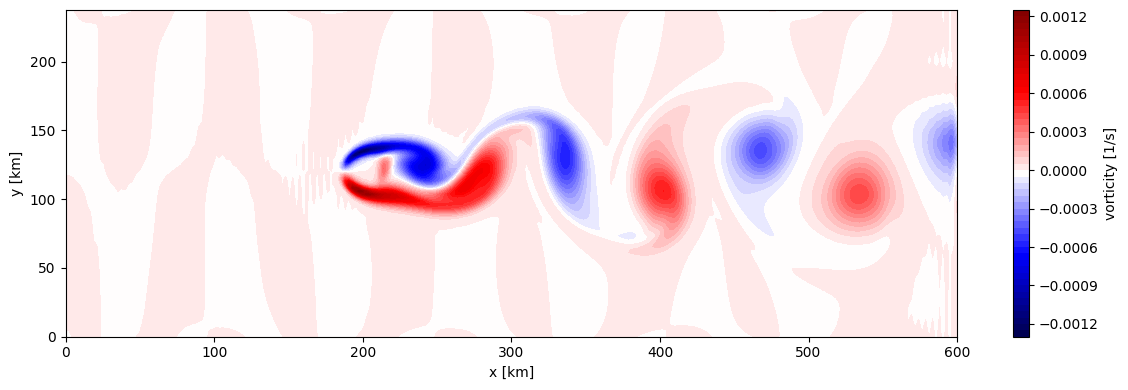

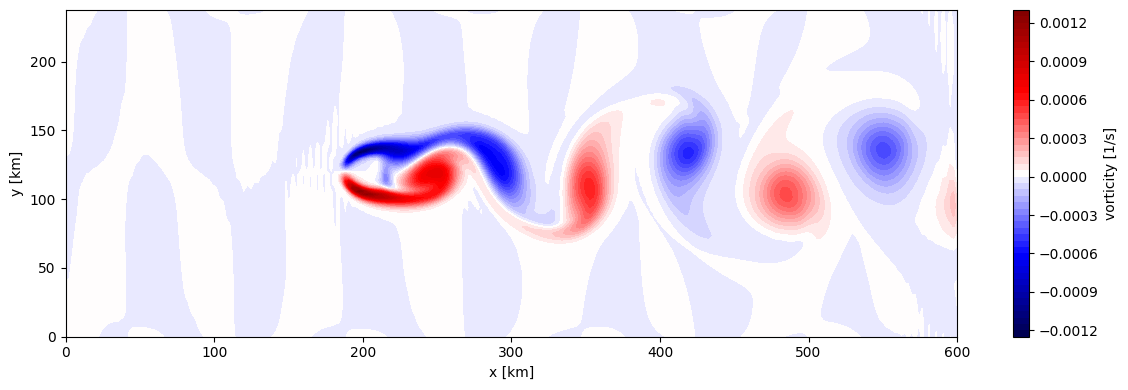

(array([[1000.        , 1427.51325797, 1019.11508088, ..., 1220.07516014,
         1220.86786177, 1220.86786177],
        [1000.        , 1427.38508709, 1019.11423652, ..., 1217.45446197,
         1218.09772916, 1218.09772916],
        [1000.        , 1427.30308462, 1019.11671546, ..., 1214.7894082 ,
         1215.27763531, 1215.27763531],
        ...,
        [1000.        , 1428.16645804, 1019.13359095, ..., 1227.59790757,
         1228.80736819, 1228.80736819],
        [1000.        , 1427.90516925, 1019.12541035, ..., 1225.15390483,
         1226.22945887, 1226.22945887],
        [1000.        , 1427.68672016, 1019.11902329, ..., 1222.64407958,
         1223.58079511, 1223.58079511]], shape=(102, 256)),
 array([[8.        , 5.17222958, 7.22103415, ..., 6.62641547, 6.627811  ,
         6.627811  ],
        [8.        , 5.17313896, 7.22114381, ..., 6.67031053, 6.67156464,
         6.67156464],
        [8.        , 5.17347457, 7.22117615, ..., 6.7139963 , 6.71510242,
         6.715102

In [32]:
update_rk2(h,u,v)